# CO2 Emmissions by cars 


## **Project Definition and Goal**<br> 



### Identifying the car technical characteristics that play a role in pollution 

<span style="font-size: 18px">

- This project aims to identify which technical characteristics<br>
of newly registered vehicles most influence their CO₂ emissions.<br>
Our goal is to uncover patterns and predictors of emissions<br>
performance that can inform sustainable vehicle design, <br>
manufacturing strategies, and environmental policy<br>

<br>
    To develop a robust and well-tested approach, we begin<br>
with a focused exploratory analysis using a 2013 dataset<br>
of cars sold in France. Once the analytical pipeline<br>
is validated on this smaller, simpler dataset,<br>
we will apply the same methodology to the<br>
full-scale European Environment Agency (EEA) 2023<br> dataset.
This ensures both efficiency in development and <br>
relevance in our final insights.<br>

## **Datasets Overview**



We'll begin our study with two datasets:

### 1. **France 2013 dataset** (initial EDA phase)

- Contains technical and environmental specifications of passenger cars sold in France in 2013  
- Includes CO₂ emissions, fuel consumption, engine power, mass, and fuel type  
- Used to prototype visualizations, hypothesis tests, and feature selection  

### 2. **EEA 2023 dataset** (main analysis phase)

- Covers all new passenger cars registered in the European Union in 2023  
- Includes updated WLTP-based CO₂ measurements and richer technical data  
- Used to produce the final results and insights relevant to current EU mobility trends  

### Column Descriptions — 2023 EEA


| Name          | Definition                                                                                                |
| ------------- | --------------------------------------------------------------------------------------------------------- |
| ID            | Identification number.                                                                                    |
| MS            | Member state.                                                                                             |
| Mp            | Manufacturer pooling.                                                                                     |
| VFN           | Vehicle family identification number.                                                                     |
| Mh            | Manufacturer name EU standard denomination .                                                              |
| Man           | Manufacturer name OEM declaration.                                                                        |
| MMS           | Manufacturer name MS registry denomination .                                                              |
| TAN           | Type approval number.                                                                                     |
| T             | Type.                                                                                                     |
| Va            | Variant.                                                                                                  |
| Ve            | Version.                                                                                                  |
| Mk            | Make.                                                                                                     |
| Cn            | Commercial name.                                                                                          |
| Ct            | Category of the vehicle type approved.                                                                    |
| Cr            | Category of the vehicle registered.                                                                       |
| M (kg)        | Mass in running order Completed/complete vehicle .                                                        |
| Mt            | WLTP test mass.                                                                                           |
| Enedc (g/km)  | Specific CO2 Emissions (NEDC).                                                                            |
| Ewltp (g/km)  | Specific CO2 Emissions (WLTP).                                                                            |
| W (mm)        | Wheel Base.                                                                                               |
| At1 (mm)      | Axle width steering axle.                                                                                 |
| At2 (mm)      | Axle width other axle.                                                                                    |
| Ft            | Fuel type.                                                                                                |
| Fm            | Fuel mode.                                                                                                |
| Ec (cm3)      | Engine capacity.                                                                                          |
| Ep (KW)       | Engine power.                                                                                             |
| Z (Wh/km)     | Electric energy consumption.                                                                              |
| IT            | Innovative technology or group of innovative technologies.                                                |
| Ernedc (g/km) | Emissions reduction through innovative technologies.                                                      |
| Erwltp (g/km) | Emissions reduction through innovative technologies (WLTP).                                               |
| De            | Deviation factor.                                                                                         |
| Vf            | Verification factor.                                                                                      |
| R             | Total new registrations.                                                                                  |
| Year          | Reporting year.                                                                                           |
| Status        | P = Provisional data, F = Final data.                                                                     |
| Version_file  | Internal versioning of deliverables.                                                                      |
| E (g/km)      | Specific CO2 Emission. Deprecated value, only relevant for data until 2016.                               |
| Er (g/km)     | Emissions reduction through innovative technologies. Deprecated value, only relevant for data until 2016. |
| Zr            | Electric range.                                                                                           |
| Dr            | Registration date.                                                                                        |
| Fc            | Fuel consumption.                                                                                         |


## **Data Loading**

In [1]:
### importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:

# 2023 France Database into df_a_a_a 

df_a = pd.read_csv('../data/raw/data_2023.csv', sep=',', encoding='utf-8')

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_94732/1031381680.py:3: DtypeWarning: Columns (2,3,28,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_a = pd.read_csv('../data/raw/data_2023.csv', sep=',', encoding='utf-8')


## **Data Exploration of Europe 2023 Data Set**

### Data Information

<span style="font-size: 16px">

#### 2023 Europe Data Frame Exploration

In [3]:
#df infos
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734656 entries, 0 to 10734655
Data columns (total 40 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Country               object 
 2   VFN                   object 
 3   Mp                    object 
 4   Mh                    object 
 5   Man                   object 
 6   MMS                   float64
 7   Tan                   object 
 8   T                     object 
 9   Va                    object 
 10  Ve                    object 
 11  Mk                    object 
 12  Cn                    object 
 13  Ct                    object 
 14  Cr                    object 
 15  r                     int64  
 16  m (kg)                float64
 17  Mt                    float64
 18  Enedc (g/km)          float64
 19  Ewltp (g/km)          float64
 20  W (mm)                float64
 21  At1 (mm)              float64
 22  At2 (mm)              float64
 23  Ft   

The following variables couldn't be matched with Table definition
- ech
- RLFI

In the table definition, the following variables couldn't be matched
- Member State
- Version_file

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

display(df_a.head())

df_a.tail()

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,130815554,DE,IP-MQB37SZ_A3_0550-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,NaN,e13*2007/46*1845*26,A1,DLAAX0AC4,FM6FM6AJ0254BI1CANNI02GA0,VOLKSWAGEN VW,T-ROC,M1,M1,1,1301.0,1414.0,NaN,143.0,NaN,NaN,NaN,petrol,M,999.0,81.0,NaN,e13 29,NaN,1.17,NaN,NaN,P,2023,2023-05-11,6.3,NaN,RL-MQ200_6F_18_019-WVW-1,NaN
1,130815555,DE,IP-0500709-TMA-1,HYUNDAI MOTOR EUROPE,HYUNDAI CZECH,HYUNDAI MOTOR MANUFACTURING CZECH SRO,NaN,e5*2018/858*00001*06,NX4E,F5P44,A61B14,HYUNDAI,TUCSON IX35,M1,M1,1,1709.0,1852.0,NaN,145.0,NaN,NaN,NaN,petrol,H,1598.0,132.0,NaN,e5 28,NaN,0.77,NaN,NaN,P,2023,2023-10-10,6.4,NaN,RL-0500710-TMA-1,NaN
2,130815556,DE,IP-03_312_0344-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,NaN,e3*2007/46*0064*69,312,AYD1B,AAA,FIAT,FIAT 500,M1,M1,1,1043.0,1135.0,NaN,106.0,NaN,NaN,NaN,petrol,H,999.0,52.0,NaN,e3 33,NaN,1.28,NaN,NaN,P,2023,2023-08-29,4.7,NaN,RL-03_312_0110-ZFA-1,NaN
3,130815557,DE,IP-FBC1NBPTL4C_000-VF1-1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,NaN,e2*2007/46*0546*32,RFB,BF2,NB6UCB430100,RENAULT,MEGANE,M1,M1,1,1316.0,1432.0,NaN,131.0,NaN,NaN,NaN,petrol,M,1332.0,103.0,NaN,e9 29 37,NaN,1.89,NaN,NaN,P,2023,2023-12-18,5.8,NaN,RL-FBCTL6A_300_000-VF1-1,NaN
4,130815558,DE,IP-MLB49_Z_B0_0694-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,NaN,e1*2001/116*0430*91,B8,A2DTPAQ1,QD7AD7CJ003RT081E19S54BIBEM1CD1,AUDI,A4 AVANT,M1,M1,1,1700.0,1866.0,NaN,158.0,NaN,NaN,NaN,diesel,H,1968.0,150.0,NaN,e13 33 37,NaN,1.99,NaN,NaN,P,2023,2023-11-20,6.0,NaN,RL-DL382_7A_19_013-WAU-1,NaN


,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
10734651,134791605,PT,IP-EHT____ML6_722D-YAR-0,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e2*2007/46*0537*19,V,E,EHTM-P2S20L(1V),TOYOTA,PROACE,M1,M1,1,1808.0,2140.0,NaN,193.0,NaN,NaN,NaN,DIESEL,M,1997.0,106.0,NaN,e2 33,NaN,1.1,NaN,NaN,P,2023,2023-12-28,7.4,NaN,NaN,NaN
10734652,134793098,PT,IP-0200-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e6*2007/46*0318*07,ZE1HE(EU M),ZWE219(W),ZWE219L-DWXNBW(2H),TOYOTA,TOYOTA COROLLA,M1,M1,1,1475.0,1574.0,NaN,106.0,NaN,NaN,NaN,PETROL,H,1798.0,72.0,NaN,e6 37,NaN,0.6,NaN,NaN,P,2023,2023-09-01,4.7,NaN,NaN,NaN
10734653,134794448,PT,IP-0206-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA MOTOR CORPORATION,TOYOTA MOTOR CORPORATION,NaN,e6*2018/858*00260*00,XW6(M),MXWH61(H),MXWH61L-AHXHBW(1A),TOYOTA,TOYOTA PRIUS PHEV,M1,M1,1,1630.0,1753.0,NaN,16.0,NaN,NaN,NaN,PETROL/ELECTRIC,P,1987.0,111.0,126.0,NaN,NaN,NaN,NaN,NaN,P,2023,2023-11-16,0.7,NaN,NaN,72.0
10734654,134795081,PT,IP-0120-JT1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e6*2007/46*0429*03,XA5P(EU M),AXAP54(N),AXAP54L-ANXGBW(1D),TOYOTA,TOYOTA RAV4,M1,M1,1,2005.0,2162.0,NaN,22.0,NaN,NaN,NaN,PETROL/ELECTRIC,P,2487.0,136.0,171.0,NaN,NaN,NaN,NaN,NaN,P,2023,2023-12-21,1.0,NaN,NaN,75.0
10734655,134796702,PT,IP-0120-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e6*2007/46*0429*02,XA5P(EU M),AXAP54(N),AXAP54L-ANXGBW(1C),TOYOTA,TOYOTA RAV4,M1,M1,1,2005.0,2162.0,NaN,22.0,NaN,NaN,NaN,PETROL/ELECTRIC,P,2487.0,136.0,166.0,NaN,NaN,NaN,NaN,NaN,P,2023,2023-10-31,1.0,NaN,NaN,75.0


### Data Translation

In [5]:
translations = {
    'ID': 'Vehicle_ID',
    'MS': 'Member_State_code',
    'Mp': 'Manufacturer_Pooling',
    'VFN': 'Vehicle_Family_id_number',
    'Mh': 'Manufacturer_Name',
    'Man': 'Manufacturer_name_OEM',
    'MMS': 'Manufacturer_name_MS',
    'Tan': 'Type_approval_number',
    'T': 'Type',
    'Va': 'Variant',
    'Ve': 'Version',
    'Mk': 'Make',
    'Cn': 'Commercial_Name',
    'Ct': 'Category_type_approved',
    'Cr': 'Category_type_registered',
    'r': 'Total_new_registrations',
    'm (kg)': 'Mass_in_Running_Order(kg)',
    'Mt': 'WLTP_test_mass',
    'Enedc (g/km)': 'CO2_Emissions_NEDC(g/km)',
    'Ewltp (g/km)': 'CO2_Emissions_WLTP(g/km)',
    'W (mm)': 'Wheelbase(mm)',
    'At1 (mm)': 'Axle_Track_1(mm)',
    'At2 (mm)': 'Axle_Track_2(mm)',
    'Ft': 'Fuel_Type',
    'Fm': 'Fuel_Mode',
    'ec (cm3)': 'Engine_Capacity(cm3)',
    'ep (KW)': 'Engine_Power(kW)',
    'z (Wh/km)': 'Electric_Energy_Consumption(Wh/km)',
    'IT': 'Innovative_Technologies',
    'Ernedc (g/km)': 'Emmission_reduction_through_innovation',
    'Erwltp (g/km)': 'Emmission_reduction_through_innovation_WLTP',
    'De': 'Deviation_factor',
    'Vf': 'Verification_factor',
    'ech': 'Electric_Charge',
    'Er (g/km)': 'CO2_Emissions(g/km)'
}



In [6]:
# Renaming columns
df_a.rename(columns=translations, inplace=True)

In [7]:
df_a.columns

Index(['Vehicle_ID', 'Country', 'Vehicle_Family_id_number',
       'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM',
       'Manufacturer_name_MS', 'Type_approval_number', 'Type', 'Variant',
       'Version', 'Make', 'Commercial_Name', 'Category_type_approved',
       'Category_type_registered', 'Total_new_registrations',
       'Mass_in_Running_Order(kg)', 'WLTP_test_mass',
       'CO2_Emissions_NEDC(g/km)', 'CO2_Emissions_WLTP(g/km)', 'Wheelbase(mm)',
       'Axle_Track_1(mm)', 'Axle_Track_2(mm)', 'Fuel_Type', 'Fuel_Mode',
       'Engine_Capacity(cm3)', 'Engine_Power(kW)',
       'Electric_Energy_Consumption(Wh/km)', 'Innovative_Technologies',
       'Emmission_reduction_through_innovation',
       'Emmission_reduction_through_innovation_WLTP', 'Deviation_factor',
       'Verification_factor', 'Status', 'year', 'Date of registration',
       'Fuel consumption ', 'Electric_Charge', 'RLFI', 'Electric range (km)'],
      dtype='object')

In [8]:
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734656 entries, 0 to 10734655
Data columns (total 40 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   Vehicle_ID                                   int64  
 1   Country                                      object 
 2   Vehicle_Family_id_number                     object 
 3   Manufacturer_Pooling                         object 
 4   Manufacturer_Name                            object 
 5   Manufacturer_name_OEM                        object 
 6   Manufacturer_name_MS                         float64
 7   Type_approval_number                         object 
 8   Type                                         object 
 9   Variant                                      object 
 10  Version                                      object 
 11  Make                                         object 
 12  Commercial_Name                              object 
 13  Category_t

In [9]:
# Null values and their percentage in each column

df_info = pd.DataFrame({
    'Column': df_a.columns,
    'Data Type': df_a.dtypes,
    'Non-Null Count': df_a.count(),
    'Null Count': df_a.isnull().sum(),
    'Null Percentage': (df_a.isnull().sum() / len(df_a) * 100).round(2)
})
print(df_info.to_string(index=False))

                                     Column Data Type  Non-Null Count  Null Count  Null Percentage
                                 Vehicle_ID     int64        10734656           0             0.00
                                    Country    object        10734656           0             0.00
                   Vehicle_Family_id_number    object        10141479      593177             5.53
                       Manufacturer_Pooling    object         9777534      957122             8.92
                          Manufacturer_Name    object        10734656           0             0.00
                      Manufacturer_name_OEM    object        10734656           0             0.00
                       Manufacturer_name_MS   float64               0    10734656           100.00
                       Type_approval_number    object        10702002       32654             0.30
                                       Type    object        10728379        6277             0.06
          

 Missing Data Analysis - Key Insights:

As the following columns are NA, they will be dropped

- Manufacturer_name_MS
- CO2_Emissions_NEDC(g/km)
- Wheelbase(mm)
- Axle_Track_1(mm)
- Axle_Track_2(mm)
- Emmission_reduction_through_innovation
- Deviation_factor
- Verification_factor

Electric Vehicle Features (High Missing %):

- Electric_Energy_Consumption(Wh/km) - 78% missing
- Electric range (km) - 78% missing
- Electric_Charge - 64% missing
- RLFI - 70% missing

Most probably the non-Electric Vehicles do not have the respective features. It should be double checked

Important Features (Moderate Missing):

- Engine_Capacity(cm3) - 15.56% missing
- Fuel consumption - 29.65% missing
- WLTP_test_mass - 4.88% missing

Clean Features (Low Missing):

- CO2_Emissions_WLTP(g/km) - 0.19% missing (our target feature)


In [10]:
columns_to_drop = [
    'Manufacturer_name_MS',
    'CO2_Emissions_NEDC(g/km)',
    'Wheelbase(mm)',
    'Axle_Track_1(mm)',
    'Axle_Track_2(mm)',
    'Emmission_reduction_through_innovation',
    'Deviation_factor',
    'Verification_factor'
]

df_a = df_a.drop(columns=columns_to_drop)


In [11]:
# Drop rows where target variable has NaN/NA values
df_a = df_a.dropna(subset=['CO2_Emissions_WLTP(g/km)'])

In [12]:
# Duplicates in the DataFrame and their percentage  

duplicates_count = df_a.duplicated().sum()
duplicates_percentage = (duplicates_count / len(df_a) * 100).round(2)
print(f"Number of duplicates: {duplicates_count} ({duplicates_percentage}%)")

Number of duplicates: 0 (0.0%)


There are no duplicates to handle for the next steps

In [13]:
pd.set_option('display.float_format', '{:.1f}'.format)
# Displaying descriptive statistics of the DataFrame
df_a.describe()

,Vehicle_ID,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Emmission_reduction_through_innovation_WLTP,year,Fuel consumption,Electric range (km)
count,10713765.0,10713765.0,10713365.0,10205226.0,10713765.0,9043496.0,10678848.0,2359609.0,5767272.0,10713765.0,7547786.0,2334701.0
mean,125983907.2,1.0,1545.6,1655.8,106.7,1543.2,115.2,171.9,1.5,2023.0,5.4,318.2
std,8060129.8,0.0,360.7,374.1,59.6,524.2,62.4,28.9,0.5,0.0,1.8,191.8
min,90240411.0,1.0,563.0,615.0,0.0,658.0,8.0,11.0,0.5,2023.0,0.1,12.0
25%,122188940.0,1.0,1270.0,1376.0,101.0,1197.0,74.0,155.0,1.1,2023.0,4.9,77.0
50%,128890021.0,1.0,1480.0,1584.0,123.0,1497.0,100.0,166.0,1.7,2023.0,5.5,380.0
75%,131879745.0,1.0,1765.0,1881.0,139.0,1968.0,132.0,179.0,2.0,2023.0,6.1,491.0
max,134796702.0,1.0,4953.0,4574.0,543.0,7993.0,1177.0,547.0,7.0,2023.0,29.0,883.0


The following numerical columns have only 1 value and they will not be used in modeling steps
- Total_new_registrations
- year

In [14]:
df_a.shape

(10713765, 32)

In [70]:
df_a.head(20)

,Vehicle_ID,Country,Vehicle_Family_id_number,Manufacturer_Pooling,Manufacturer_Name,Manufacturer_name_OEM,Type_approval_number,Type,Variant,Version,...,Electric_Energy_Consumption(Wh/km),Innovative_Technologies,Emmission_reduction_through_innovation_WLTP,Status,year,Date of registration,Fuel consumption,Electric_Charge,RLFI,Electric range (km)
0,130815554,DE,IP-MQB37SZ_A3_0550-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e13*2007/46*1845*26,A1,DLAAX0AC4,FM6FM6AJ0254BI1CANNI02GA0,...,NaN,e13 29,1.2,P,2023,2023-05-11,6.3,NaN,RL-MQ200_6F_18_019-WVW-1,NaN
1,130815555,DE,IP-0500709-TMA-1,HYUNDAI MOTOR EUROPE,HYUNDAI CZECH,HYUNDAI MOTOR MANUFACTURING CZECH SRO,e5*2018/858*00001*06,NX4E,F5P44,A61B14,...,NaN,e5 28,0.8,P,2023,2023-10-10,6.4,NaN,RL-0500710-TMA-1,NaN
2,130815556,DE,IP-03_312_0344-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,e3*2007/46*0064*69,312,AYD1B,AAA,...,NaN,e3 33,1.3,P,2023,2023-08-29,4.7,NaN,RL-03_312_0110-ZFA-1,NaN
3,130815557,DE,IP-FBC1NBPTL4C_000-VF1-1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,e2*2007/46*0546*32,RFB,BF2,NB6UCB430100,...,NaN,e9 29 37,1.9,P,2023,2023-12-18,5.8,NaN,RL-FBCTL6A_300_000-VF1-1,NaN
4,130815558,DE,IP-MLB49_Z_B0_0694-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,e1*2001/116*0430*91,B8,A2DTPAQ1,QD7AD7CJ003RT081E19S54BIBEM1CD1,...,NaN,e13 33 37,2.0,P,2023,2023-11-20,6.0,NaN,RL-DL382_7A_19_013-WAU-1,NaN
5,130815559,DE,IP-MQB37SZ_A3_1035-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e13*2007/46*1845*27,A1,DXDBX0AC4,FD7FD7CW0064BI1CANNI02GA0,...,NaN,e13 29,1.2,P,2023,2023-07-12,6.4,NaN,RL-DQ200_7F_17_012-WVW-1,NaN
6,130815560,DE,IP-JFB1M6PJT4A_000-UU1-0,RENAULT-NISSAN-MITSUBISHI,DACIA,AUTOMOBILE DACIA SA,e19*2007/46*0026*15,DJF,BEV,M66UA43M5200,...,NaN,e19 29 37,1.9,P,2023,2023-03-02,5.6,NaN,RL-JFAJT4A_220_000-UU1-0,NaN
7,130815561,DE,IP-MQB37WZ_A0_0591-TMB-1,VOLKSWAGEN,SKODA,SKODA AUTO AS,e8*2007/46*0355*12,NX,ACDTTCX0,NFD7FD7GC0024BIVL0C1A1A,...,NaN,e8 29 37,1.7,P,2023,2023-01-05,4.5,NaN,RL-DQ381_7F_19_001-WVW-1,NaN
8,130815562,DE,IP-041225-U5Y-1,KIA,KIA SLOVAKIA,KIA SLOVAKIA SRO,e4*2007/46*1299*18,CD,F5P61,D61LZ1,...,125.0,NaN,NaN,P,2023,2023-04-27,1.5,NaN,RL-041203-U5Y-1,55.0
9,130815563,DE,IP-AP992002GTSAT00-WP0-1,VOLKSWAGEN,PORSCHE,DR ING HCF PORSCHE AG,e13*2007/46*0992*15,992,CC12,3410000,...,NaN,e1 33,0.9,P,2023,2023-10-17,10.9,NaN,RL-992002AT80ZZZ03-WP0-1,NaN


### Some Notes
- Not sure if Category_type_registered & Category_type_approved mean the same and how to interpret them

- Some name related fixes are necessary for Fuel_Type

- Fuel_Mode & Fuel_Type relation should be clarified

- How to translate Innovative technologies and it's impact 
- How to translate Emmission_reduction_through_innovation_WLTP 
- Is there any relationship between respective variables?

- Electric_Charge, RLFI, Electric range (km) they could be electricty-only related features

In [ ]:
pd.crosstab(df_a['Category_type_registered'], 
           df_a['Category_type_approved'], 
           margins=True)

# Not sure about the meaning of these columns, so dropping them might be a good idea

Category_type_approved,M1,M1G,N1,N1G,N2,N2G,All
Category_type_registered,,,,,,,
M1,10323448,3048,423,4,2,0,10326925
M1G,1519,372010,0,22,0,1,373552
All,10324967,375058,423,26,2,1,10700477


In [19]:
df_a['Fuel_Type'].value_counts()

Fuel_Type
petrol             6003101
diesel             1821098
electric           1669449
petrol/electric     826370
lpg                 309128
e85                  46157
diesel/electric      30264
ng                    7362
hydrogen               730
PETROL                  59
PETROL/ELECTRIC         28
DIESEL                  17
ELECTRIC                 1
LPG                      1
Name: count, dtype: int64

In [20]:
# Create a mapping dictionary for standardization
fuel_mapping = {
    'PETROL': 'petrol',
    'DIESEL': 'diesel', 
    'ELECTRIC': 'electric',
    'PETROL/ELECTRIC': 'petrol/electric',
    'LPG': 'lpg'
}

# Apply the mapping
df_a['Fuel_Type'] = df_a['Fuel_Type'].replace(fuel_mapping)

# Check the result
print(df_a['Fuel_Type'].value_counts())

Fuel_Type
petrol             6003160
diesel             1821115
electric           1669450
petrol/electric     826398
lpg                 309129
e85                  46157
diesel/electric      30264
ng                    7362
hydrogen               730
Name: count, dtype: int64


In [ ]:
pd.crosstab(df_a['Fuel_Type'], 
           df_a['Fuel_Mode'], 
           margins=True)

# How to map the respective varibles should be thought through

Fuel_Mode,B,E,F,H,M,P,All
Fuel_Type,,,,,,,
diesel,0,0,0,441320,1379795,0,1821115
diesel/electric,0,0,0,0,0,30264,30264
e85,0,0,7325,38832,0,0,46157
electric,0,1669450,0,0,0,0,1669450
hydrogen,1,0,0,0,729,0,730
lpg,309022,0,0,0,107,0,309129
ng,588,0,0,0,6774,0,7362
petrol,0,0,0,2265443,3737717,0,6003160
petrol/electric,0,0,0,0,0,826398,826398


In [27]:
# Checking electic related variables 
pd.crosstab(df_a['Fuel_Type'], 
           df_a['Electric_Charge'], 
           margins=True)
# Electric_Charge is not only relevant for electric vehicles


Electric_Charge,2018/1832AP,2018/1832AX,6EA,AP,AR,AX,AY,AZ,EA,EU 2018/1832AP,EURO 6 AP,EURO 6 AQ,EURO 6 AR,EURO 6 AX,EURO 6 AZ,EURO 6 CI,EURO 6 EA,EURO 6AP,EURO 6AZ,EURO 6D,EURO 6EA,EURO AX,EURO AY,EURO VI,EURO VI E,EURO VIE,Euro 6,Euro 6 AP,Euro 6 AQ,Euro 6 AR,Euro 6 EA,Euro AX,Euro VI,Euro VI E,RL-0067-JT1-1,VI-E,All
Fuel_Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
diesel,35,0,0,25393,4,0,0,0,468,0,56445,6,41,0,0,1,887,173984,0,0,3183,0,0,0,55,0,329,259493,1,5,7429,0,0,39,0,0,527798
diesel/electric,0,0,0,190,0,0,0,0,0,0,3108,0,0,0,0,0,2,1712,0,0,1,0,0,0,0,0,0,5047,0,0,4,0,0,0,0,0,10064
e85,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,40652,0,0,236,0,0,0,0,0,40888
electric,0,7,0,76,0,427601,0,0,0,0,0,0,1,4182,0,0,0,0,0,0,0,55110,0,5,82,169,0,26033,0,0,0,1,10,626,0,1,513904
hydrogen,0,0,0,0,0,0,317,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0,0,0,0,1,0,0,0,0,0,0,0,0,326
lpg,0,0,0,6054,0,0,0,0,200,0,4180,0,0,0,0,0,2,25654,0,1,540,0,0,0,0,0,0,63236,0,0,657,0,0,0,0,0,100524
ng,0,0,0,502,0,0,0,0,0,0,157,0,0,0,0,0,0,145,0,0,0,0,0,0,0,0,0,172,0,0,0,0,0,0,0,0,976
petrol,702,0,3,119290,0,1,0,178,459,1,304837,0,0,0,2,0,3158,640313,41,2,11107,0,0,0,0,0,995,1206204,0,0,35633,0,0,0,2,0,2322928
petrol/electric,3,0,0,9572,0,2,0,0,282,0,97202,0,0,0,0,0,2317,57994,0,0,1856,0,0,0,0,0,118,179192,0,0,6345,0,0,0,0,0,354883


In [28]:
pd.crosstab(df_a['Fuel_Type'], 
           df_a['Electric_Energy_Consumption(Wh/km)'], 
           margins=True)

# That is related to electric but there are some values still associated with petrol and diesel

Electric_Energy_Consumption(Wh/km),11.0,12.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,27.0,29.0,30.0,31.0,33.0,37.0,42.0,43.0,44.0,45.0,46.0,47.0,48.0,51.0,52.0,53.0,54.0,55.0,56.0,57.0,59.0,60.0,61.0,62.0,63.0,64.0,65.0,66.0,67.0,68.0,69.0,70.0,71.0,72.0,73.0,74.0,75.0,76.0,77.0,80.0,81.0,82.0,84.0,85.0,86.0,87.0,89.0,91.0,98.0,99.0,100.0,102.0,103.0,105.0,106.0,107.0,109.0,111.0,112.0,113.0,114.0,116.0,117.0,119.0,120.0,122.0,123.0,124.0,125.0,126.0,127.0,128.0,129.0,130.0,131.0,132.0,133.0,134.0,135.0,136.0,137.0,138.0,139.0,140.0,141.0,142.0,143.0,144.0,145.0,146.0,147.0,148.0,149.0,150.0,151.0,152.0,153.0,154.0,155.0,156.0,157.0,158.0,159.0,160.0,161.0,162.0,163.0,164.0,165.0,166.0,167.0,168.0,169.0,170.0,171.0,172.0,173.0,174.0,175.0,176.0,177.0,178.0,179.0,180.0,181.0,182.0,183.0,184.0,185.0,186.0,187.0,188.0,189.0,190.0,191.0,192.0,193.0,194.0,195.0,196.0,197.0,198.0,199.0,200.0,201.0,202.0,203.0,204.0,205.0,206.0,207.0,208.0,209.0,210.0,211.0,212.0,213.0,214.0,215.0,216.0,217.0,218.0,219.0,220.0,221.0,222.0,223.0,224.0,225.0,226.0,227.0,228.0,229.0,230.0,231.0,232.0,233.0,234.0,235.0,236.0,237.0,238.0,239.0,240.0,241.0,242.0,243.0,244.0,245.0,246.0,247.0,248.0,249.0,250.0,251.0,252.0,253.0,254.0,255.0,256.0,257.0,258.0,259.0,260.0,261.0,262.0,263.0,264.0,265.0,266.0,267.0,268.0,269.0,270.0,271.0,272.0,273.0,274.0,275.0,276.0,277.0,278.0,279.0,280.0,281.0,282.0,283.0,284.0,285.0,286.0,287.0,288.0,289.0,290.0,291.0,292.0,293.0,294.0,295.0,296.0,297.0,298.0,299.0,300.0,301.0,302.0,303.0,304.0,305.0,306.0,307.0,308.0,309.0,310.0,311.0,312.0,313.0,314.0,315.0,316.0,317.0,318.0,319.0,320.0,321.0,322.0,323.0,324.0,325.0,326.0,327.0,328.0,329.0,330.0,331.0,332.0,333.0,334.0,335.0,336.0,337.0,338.0,339.0,340.0,341.0,342.0,343.0,344.0,345.0,346.0,347.0,348.0,349.0,350.0,351.0,352.0,353.0,354.0,355.0,356.0,357.0,358.0,359.0,360.0,361.0,362.0,363.0,364.0,365.0,366.0,368.0,369.0,370.0,371.0,372.0,373.0,374.0,375.0,376.0,377.0,378.0,379.0,380.0,385.0,386.0,388.0,389.0,391.0,394.0,395.0,396.0,399.0,400.0,401.0,403.0,405.0,406.0,407.0,408.0,410.0,412.0,413.0,414.0,415.0,416.0,417.0,418.0,419.0,420.0,421.0,422.0,423.0,424.0,425.0,426.0,427.0,428.0,429.0,430.0,432.0,433.0,434.0,435.0,436.0,437.0,440.0,443.0,446.0,447.0,449.0,450.0,454.0,455.0,456.0,459.0,460.0,462.0,464.0,465.0,466.0,467.0,468.0,472.0,475.0,476.0,477.0,478.0,481.0,482.0,483.0,484.0,485.0,487.0,489.0,490.0,491.0,492.0,499.0,500.0,502.0,505.0,506.0,507.0,510.0,511.0,513.0,514.0,516.0,519.0,522.0,524.0,525.0,528.0,531.0,533.0,535.0,542.0,543.0,546.0,547.0,All
Fuel_Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
diesel,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
diesel/electric,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,3,0,0,0,43,0,0,0,0,0,2,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [71]:
tech_values = ['e2 29 37', 'e9 29 37', 'e6 37', 'e1 29', 'e13 29', 'e13 29 37', 'e8 29 37']

result = []
for tech in tech_values:
    emissions = df_a[df_a['Innovative_Technologies'] == tech]['Emmission_reduction_through_innovation_WLTP'].unique()
    result.append({'Technology': tech, 'Emission_Reductions': list(emissions)})

pd.DataFrame(result)

,Technology,Emission_Reductions
0,e2 29 37,"[2.06, 1.36, 2.14, 2.12, 1.95, 1.58, 1.64, 1.8..."
1,e9 29 37,"[1.89, 1.96, 1.7, 1.9, 1.88, 1.75, 1.71, 2.3, ..."
2,e6 37,"[0.8, 0.7, 0.6, 0.78, 0.9, 0.92, 0.5, 0.68, 0...."
3,e1 29,"[1.0, 1.14, 1.2, 1.1, 1.02, 1.4, 0.78, 1.08, 0..."
4,e13 29,"[1.17, 1.13, 1.0, 1.34, 1.04, 1.2, 1.7, 1.1, n..."
5,e13 29 37,"[1.66, 2.03, 1.71, 1.96, 1.84, 1.74, 2.04, 2.0..."
6,e8 29 37,"[1.74, 2.06, 1.61, 1.78, 1.67, 1.95, 2.0, 1.53..."


As you can see above, Innovative Technology and Emission Reductions are not matching one-to-one

In [29]:
# Converting 'Date of registration' to datetime format
df_a['Date of registration'] = pd.to_datetime(df_a['Date of registration'], errors='coerce')


np.float64(1520.75)

Number of outliers in 'Mass_in_Running_Order(kg)': 147197


Text(0.5, 0, 'Mass in Running Order (kg)')

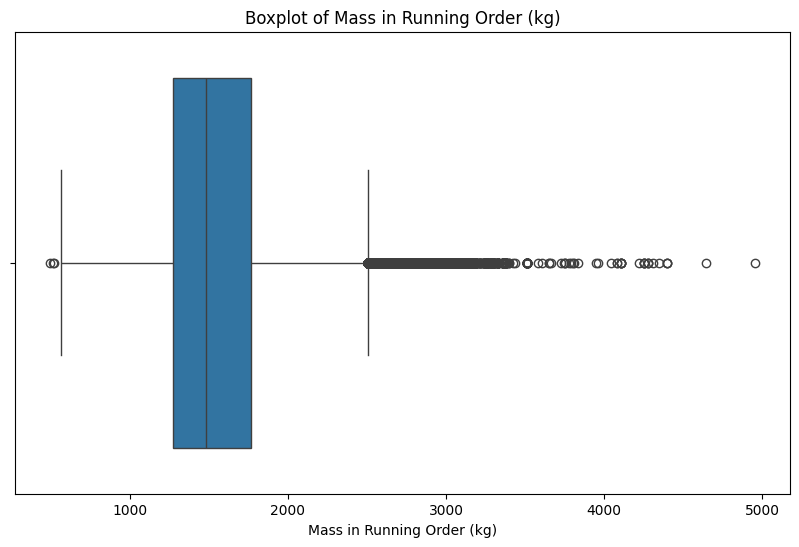

In [16]:
display(df_a['Mass_in_Running_Order(kg)'].head(20).mean())
# Checking for outliers in 'Mass_in_Running_Order(kg)' using IQR method
Q1 = df_a['Mass_in_Running_Order(kg)'].quantile(0.25)
Q3 = df_a['Mass_in_Running_Order(kg)'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_a[(df_a['Mass_in_Running_Order(kg)'] < (Q1 - 1.5 * IQR)) | (df_a['Mass_in_Running_Order(kg)'] > (Q3 + 1.5 * IQR))]
print(f"Number of outliers in 'Mass_in_Running_Order(kg)': {len(outliers)}")
# Visualizing the distribution of 'Mass_in_Running_Order(kg)'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_a['Mass_in_Running_Order(kg)'])
plt.title('Boxplot of Mass in Running Order (kg)')
plt.xlabel('Mass in Running Order (kg)')    

Number of outliers in 'WLTP_test_mass': 166119


Text(0.5, 1.0, 'Boxplot of WLTP Test Mass')

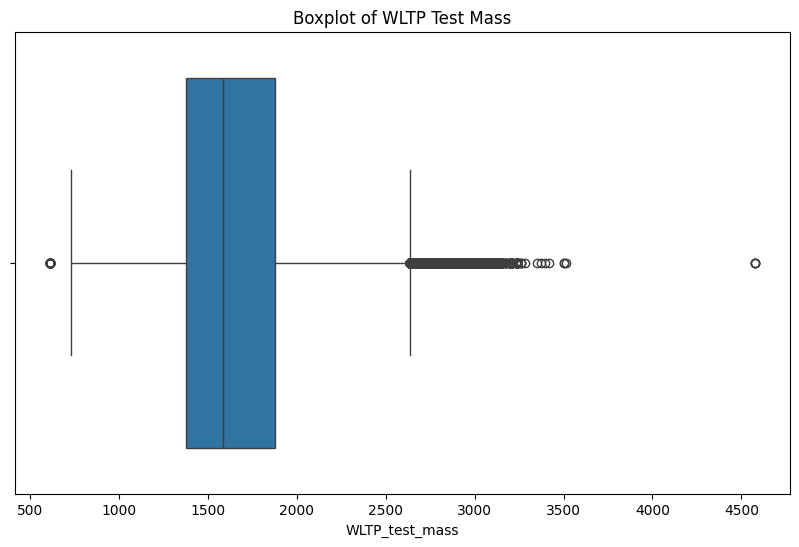

In [17]:
df_a['WLTP_test_mass'].describe()
# Checking for outliers in 'WLTP_test_mass' using IQR method
Q1_wltp = df_a['WLTP_test_mass'].quantile(0.25)
Q3_wltp = df_a['WLTP_test_mass'].quantile(0.75)
IQR_wltp = Q3_wltp - Q1_wltp
outliers_wltp = df_a[(df_a['WLTP_test_mass'] < (Q1_wltp - 1.5 * IQR_wltp)) | (df_a['WLTP_test_mass'] > (Q3_wltp + 1.5 * IQR_wltp))]
print(f"Number of outliers in 'WLTP_test_mass': {len(outliers_wltp)}") 
# Visualizing the distribution of 'WLTP_test_mass'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_a['WLTP_test_mass'])
plt.title('Boxplot of WLTP Test Mass')              

In [18]:
categorical_columns = df_a.select_dtypes(include=['object']).columns
print(f"Categorical columns found: {list(categorical_columns)}")

for col in categorical_columns:
    unique_count = df_a[col].nunique()
    print(f"\n{col}:")
    print(f"  - Unique values: {unique_count}")
    
    # Get value counts and percentages
    value_counts = df_a[col].value_counts()
    percentages = df_a[col].value_counts(normalize=True) * 100
    
    if unique_count <= 10:
        print(f"  - All values with distribution:")
        display_data = list(zip(value_counts.index, value_counts.values, percentages.values))
    else:
        print(f"  - Top 10 values with distribution:")
        display_data = list(zip(value_counts.head(10).index, value_counts.head(10).values, percentages.head(10).values))
    
    for val, count, pct in display_data:
        print(f"    {val}: {count} ({pct:.1f}%)")

Categorical columns found: ['Country', 'Vehicle_Family_id_number', 'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM', 'Type_approval_number', 'Type', 'Variant', 'Version', 'Make', 'Commercial_Name', 'Category_type_approved', 'Category_type_registered', 'Fuel_Type', 'Fuel_Mode', 'Innovative_Technologies', 'Status', 'Electric_Charge', 'RLFI']

Country:
  - Unique values: 29
  - Top 10 values with distribution:
    DE: 2765140 (25.8%)
    FR: 1889599 (17.6%)
    IT: 1564184 (14.6%)
    ES: 974231 (9.1%)
    BE: 477251 (4.4%)
    PL: 474735 (4.4%)
    NL: 364769 (3.4%)
    SE: 294548 (2.7%)
    AT: 238567 (2.2%)
    CZ: 217151 (2.0%)

Vehicle_Family_id_number:
  - Unique values: 8698
  - Top 10 values with distribution:
    IP-03_312_0344-ZFA-1: 191790 (1.9%)
    IP-0153-JT1-1: 118979 (1.2%)
    IP-0110-JT1-1: 94941 (0.9%)
    IP-JAA1MTPJT4A_000-VF1-1: 82075 (0.8%)
    IP-JFB1MTGJT4A_000-UU1-0: 69013 (0.7%)
    IP-HMH____MA5_5312-VR3-0: 62616 (0.6%)
    IP-HMR____MA5_131

### General Overview of Categorical Variables


- The most of the variable should be interpreted properly. We don't know how to interpret the values in the following categorical variables: 
    - Vehicle_Family_id_number
    - Type_approval_number
    - Type
    - Variant
    - Version
    - Category_type_approved
    - Fuel_Mode
    - Innovative_Technologies
    - Electric_Charge
    - RLFI



## TARGET VARIABLE ANALYSIS: CO2 (g/km)

In [19]:
### TARGET VARIABLE ANALYSIS: CO2 (g/km)

display(df_a['CO2_Emissions_WLTP(g/km)'].describe())

count   10713765.0
mean         106.7
std           59.6
min            0.0
25%          101.0
50%          123.0
75%          139.0
max          543.0
Name: CO2_Emissions_WLTP(g/km), dtype: float64

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_90889/1892595897.py:31: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


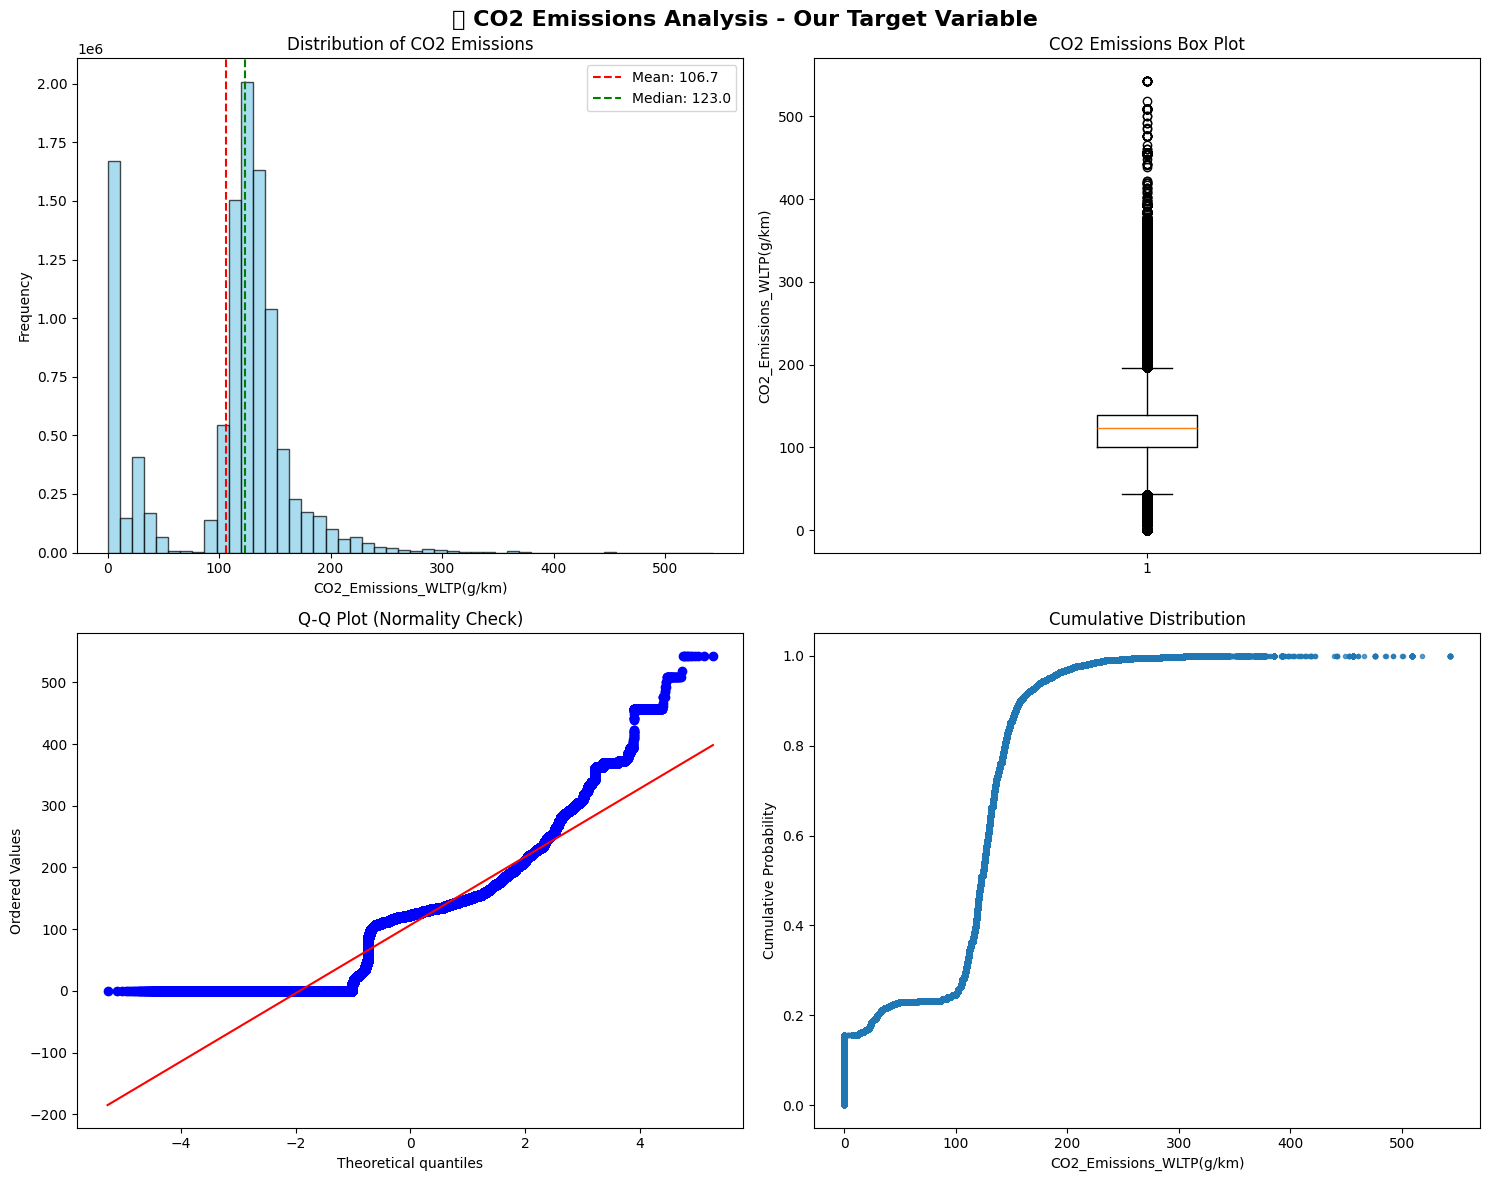

In [20]:
# Create comprehensive CO2 analysis plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 CO2 Emissions Analysis - Our Target Variable', fontsize=16, fontweight='bold')

# Distribution histogram
axes[0,0].hist(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].mean(), color='red', linestyle='--', label=f'Mean: {df_a["CO2_Emissions_WLTP(g/km)"].mean():.1f}')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].median(), color='green', linestyle='--', label=f'Median: {df_a["CO2_Emissions_WLTP(g/km)"].median():.1f}')
axes[0,0].set_title('Distribution of CO2 Emissions')
axes[0,0].set_xlabel('CO2_Emissions_WLTP(g/km)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Box plot
axes[0,1].boxplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna())
axes[0,1].set_title('CO2 Emissions Box Plot')
axes[0,1].set_ylabel('CO2_Emissions_WLTP(g/km)')

# Q-Q plot for normality
stats.probplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Normality Check)')

# Cumulative distribution
sorted_co2 = np.sort(df_a['CO2_Emissions_WLTP(g/km)'].dropna())
y = np.arange(1, len(sorted_co2) + 1) / len(sorted_co2)
axes[1,1].plot(sorted_co2, y, marker='.', linestyle='none', alpha=0.7)
axes[1,1].set_title('Cumulative Distribution')
axes[1,1].set_xlabel('CO2_Emissions_WLTP(g/km)')
axes[1,1].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()


The 0 and close to 0 CO2 emission values are most probably the electric cars. They should be investigated properly to understand what is the feature that distinguish them

In [30]:
# Displaying the features of CO2 Emissions free rows
df_a_CO2free = df_a[df_a['CO2_Emissions_WLTP(g/km)'] == 0]

display(df_a_CO2free['Fuel_Type'].value_counts())
display(df_a_CO2free['Fuel_Mode'].value_counts())


Fuel_Type
electric    1669450
hydrogen        730
Name: count, dtype: int64

Fuel_Mode
E    1669450
M        729
B          1
Name: count, dtype: int64

In [31]:
# Displaying the rows that have less than 50 g/km CO2 emissions
low_50_co2 = df_a[(df_a['CO2_Emissions_WLTP(g/km)'] < 50) & (df_a['CO2_Emissions_WLTP(g/km)'] > 0)]
print(f"Number of vehicles with CO2 emissions less than 50 g/km but not O: {len(low_50_co2)}")
# Displaying the rows with CO2 emissions less than 50 g/km
display(low_50_co2.head(5))

display(low_50_co2['Fuel_Type'].value_counts())

Number of vehicles with CO2 emissions less than 50 g/km but not O: 783013


,Vehicle_ID,Country,Vehicle_Family_id_number,Manufacturer_Pooling,Manufacturer_Name,Manufacturer_name_OEM,Type_approval_number,Type,Variant,Version,Make,Commercial_Name,Category_type_approved,Category_type_registered,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Innovative_Technologies,Emmission_reduction_through_innovation_WLTP,Status,year,Date of registration,Fuel consumption,Electric_Charge,RLFI,Electric range (km)
8,130815562,DE,IP-041225-U5Y-1,KIA,KIA SLOVAKIA,KIA SLOVAKIA SRO,e4*2007/46*1299*18,CD,F5P61,D61LZ1,KIA,CEED,M1,M1,1,1614.0,1750.0,33.0,petrol/electric,P,1580.0,77.0,125.0,NaN,NaN,P,2023,2023-04-27,1.5,NaN,RL-041203-U5Y-1,55.0
42,130815596,DE,IP-2021_3403-W1K-1,MERCEDES-BENZ AG,MERCEDES-BENZ AG,MERCEDES-BENZ AG,e1*2007/46*1560*33,R1ES,U21IT1,CZAA050E,MERCEDES-BENZ,E 300 DE 4MATIC,M1,M1,1,2215.0,2382.0,38.0,diesel/electric,P,1950.0,143.0,165.0,NaN,NaN,P,2023,2023-08-04,1.5,NaN,RL-2017_0220-WDB-1,47.0
79,130815633,DE,IP-MQB37AZ_B1_1935-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e1*2001/116*0450*68,5N,ACDGEAX0,FD6FD6DD002N5T6NVR24BI1BSB0M10SO,VOLKSWAGEN VW,TIGUAN,M1,M1,1,1816.0,2035.0,36.0,petrol/electric,P,1395.0,110.0,175.0,NaN,NaN,P,2023,2023-07-26,1.6,NaN,RL-DQ400E6F_20_001-WVW-1,52.0
82,130815636,DE,IP-MQB37AZ_A1_1935-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e1*2001/116*0450*67,5N,ACDGEAX0,FD6FD6DD002N5T6NVR24BI1BSA0M10SO,VOLKSWAGEN VW,TIGUAN,M1,M1,1,1816.0,1985.0,35.0,petrol/electric,P,1395.0,110.0,173.0,NaN,NaN,P,2023,2023-03-01,1.5,NaN,RL-DQ400E6F_20_001-WVW-1,53.0
106,130815660,DE,IP-VN41TZZ_A4_0474-WVN-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e1*2018/858*00018*08,ST,MDGEAX0,MNFD6FD6DD00217T4BI1A700A,VOLKSWAGEN VW,MULTIVAN,M1,M1,1,2194.0,2382.0,42.0,petrol/electric,P,1395.0,110.0,173.0,NaN,NaN,P,2023,2023-10-11,1.9,NaN,RL-DQ400E6F_20_701-WVN-1,47.0


Fuel_Type
petrol/electric    757754
diesel/electric     25239
petrol                 19
diesel                  1
Name: count, dtype: int64

As the extreme values are legit, we cannot remove them from the dataset

## **Correlation between variables**

### Correlation matrix

Correlation with CO2 emissions:
CO2_Emissions_WLTP(g/km)                           1.
Fuel consumption                                   0.96
Engine_Capacity(cm3)                               0.29
Electric_Energy_Consumption(Wh/km)                 0.22
Emmission_reduction_through_innovation_WLTP        0.04
Engine_Power(kW)                                   -0.12
WLTP_test_mass                                     -0.24
Mass_in_Running_Order(kg)                          -0.29
Electric range (km)                                -0.76


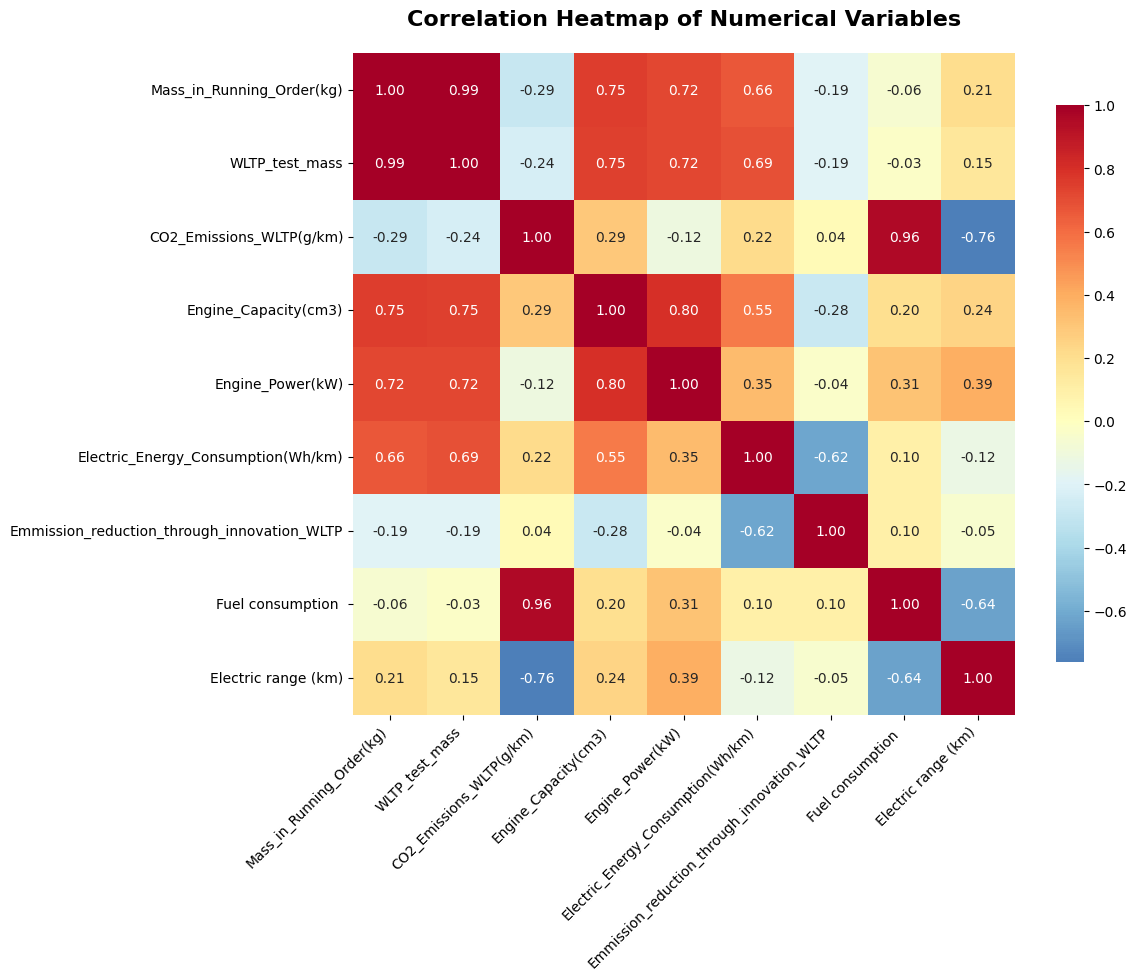

In [82]:
# Correlation analysis with CO2 emissions
# Selecting numerical columns for correlation analysis
numerical_cols = df_a.select_dtypes(include=[np.number]).columns
columns_to_exclude = ['Total_new_registrations', 'year', 'Vehicle_ID']
numerical_cols_filtered = numerical_cols.drop(columns_to_exclude)

#display(numerical_cols)

corr_with_co2 = df_a[numerical_cols_filtered].corr()['CO2_Emissions_WLTP(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
for var, corr_val in corr_with_co2.items():
    print(f"{var:<50} {np.format_float_positional(corr_val, precision=2)}")


# Create correlation matrix for all numerical columns
correlation_matrix = df_a[numerical_cols_filtered].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='RdYlBu_r',      # Color scheme (red-yellow-blue reversed)
            center=0,             # Center colormap at 0
            square=True,          # Make cells square-shaped
            fmt='.2f',            # Format numbers to 2 decimal places
            cbar_kws={'shrink': 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation with CO2 emissions:
CO2_Emissions_WLTP(g/km)                       1.0
Fuel consumption                               1.0
Engine_Capacity(cm3)                           0.3
Electric_Energy_Consumption(Wh/km)             0.2
Vehicle_ID                                     0.2
Emmission_reduction_through_innovation_WLTP    0.0
Engine_Power(kW)                              -0.1
WLTP_test_mass                                -0.2
Mass_in_Running_Order(kg)                     -0.3
Electric range (km)                           -0.8
Total_new_registrations                        NaN
year                                           NaN
Name: CO2_Emissions_WLTP(g/km), dtype: float64


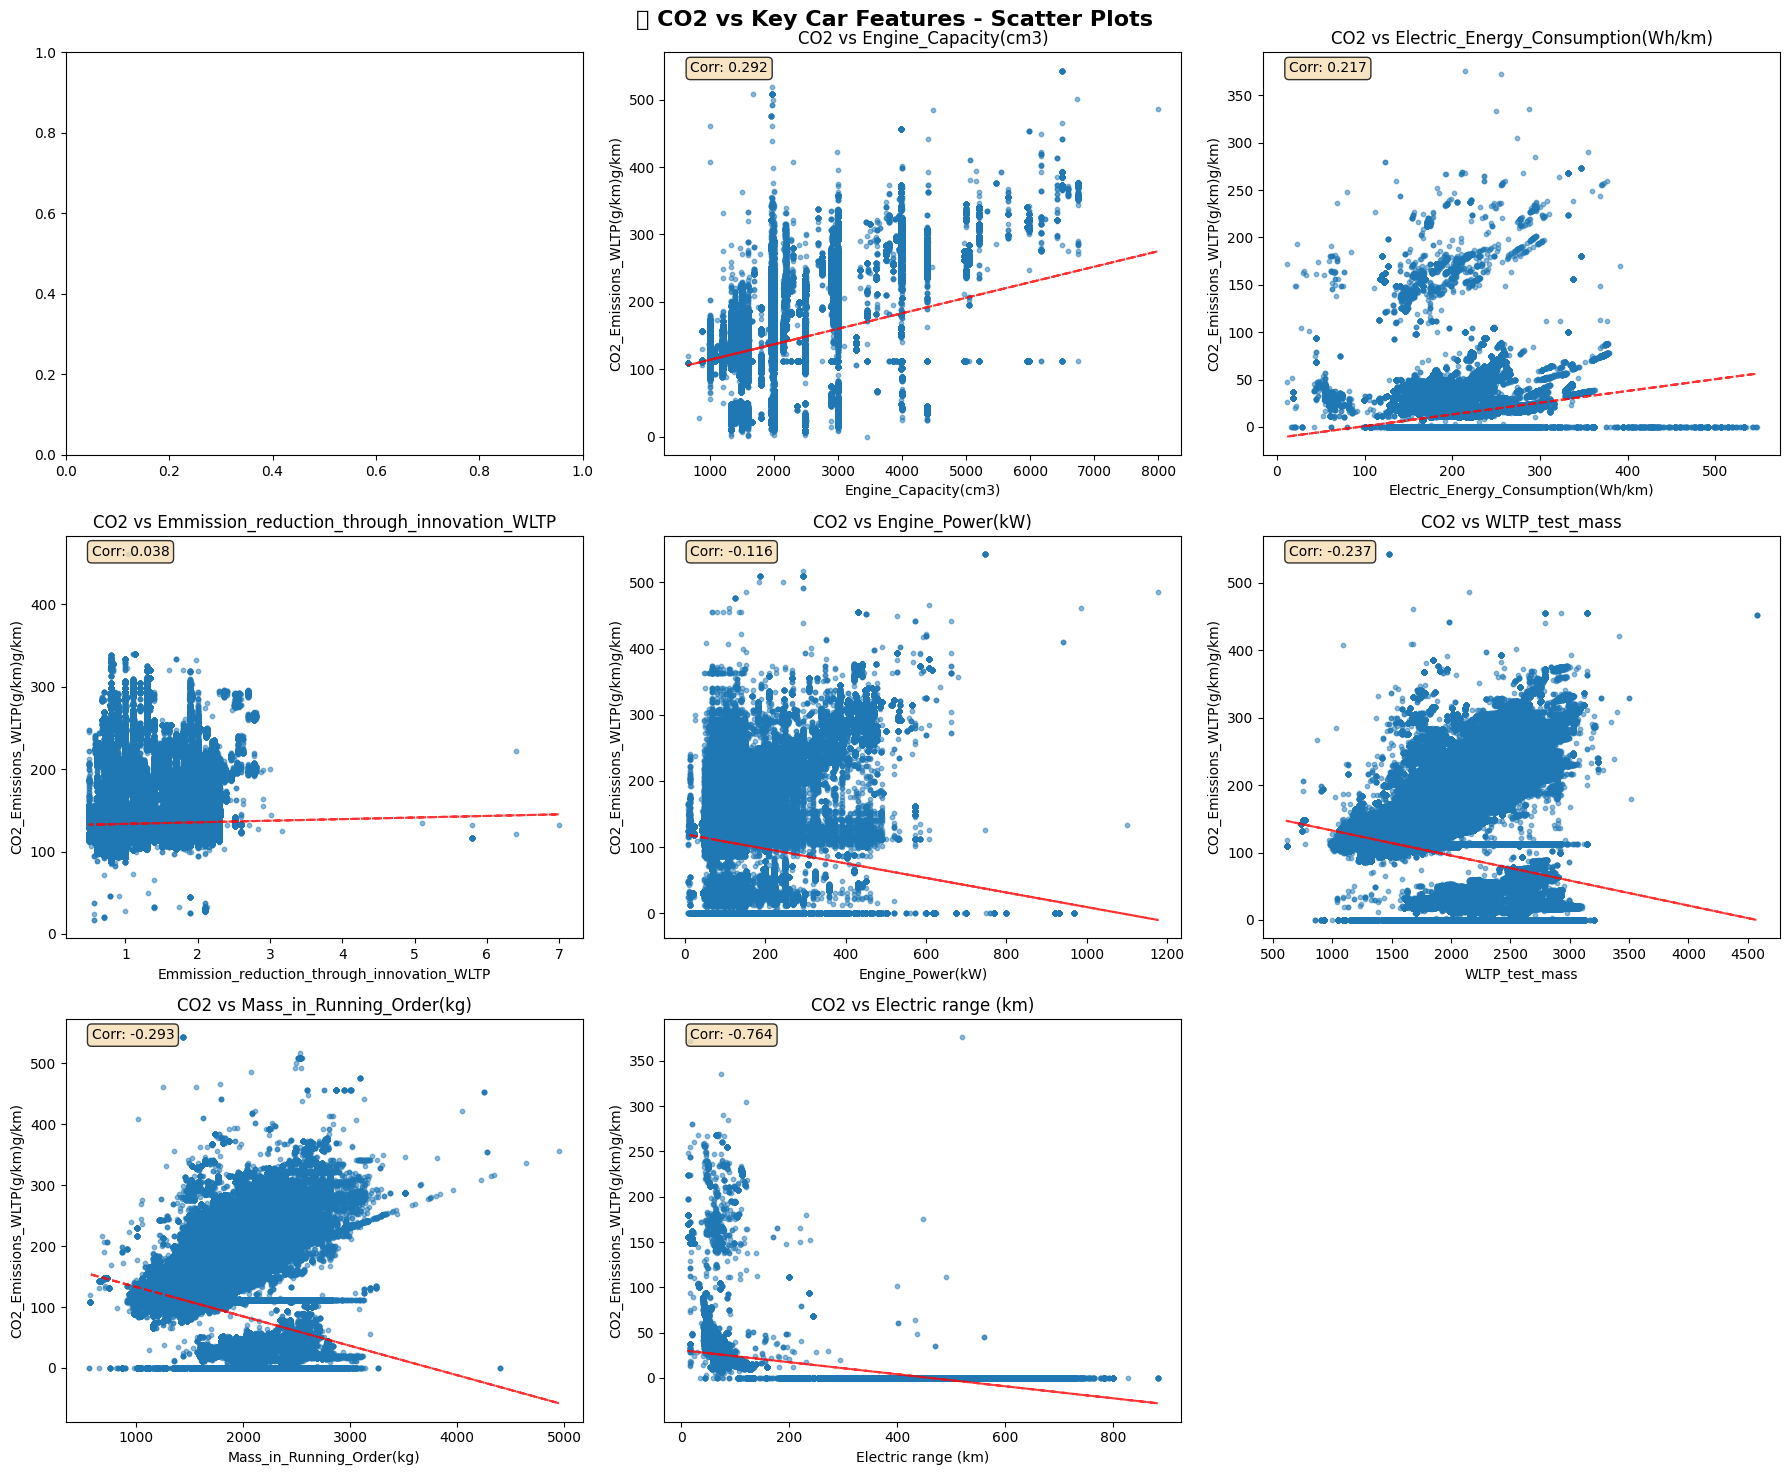

In [72]:
# KEY RELATIONSHIPS: CO2 vs NUMERICAL FEATURES

key_numerical = ['Fuel_Consumption',
                 'Engine_Capacity(cm3)',
                 'Electric_Energy_Consumption(Wh/km)',
                 'Emmission_reduction_through_innovation_WLTP',
                 'Engine_Power(kW)',
                 'WLTP_test_mass',
                 'Mass_in_Running_Order(kg)',
                 'Electric range (km)']


numerical_cols = df_a.select_dtypes(include=[np.number]).columns
corr_with_co2 = df_a[numerical_cols].corr()['CO2_Emissions_WLTP(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
print(corr_with_co2)

import math

# Scatter plots for key relationships
n_features = len(key_numerical)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
fig.suptitle('🔍 CO2 vs Key Car Features - Scatter Plots', fontsize=16, fontweight='bold')

# Flatten axes for easy indexing
axes = axes.flatten() if n_features > 1 else [axes]

for i, feature in enumerate(key_numerical):
    if feature in df_a.columns:
        clean_data = df_a[[feature, 'CO2_Emissions_WLTP(g/km)']].dropna()
        axes[i].scatter(clean_data[feature], clean_data['CO2_Emissions_WLTP(g/km)'], alpha=0.5, s=10)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('CO2_Emissions_WLTP(g/km)g/km)')
        axes[i].set_title(f'CO2 vs {feature}')
        # Add trend line
        if len(clean_data) > 1:
            z = np.polyfit(clean_data[feature], clean_data['CO2_Emissions_WLTP(g/km)'], 1)
            p = np.poly1d(z)
            axes[i].plot(clean_data[feature], p(clean_data[feature]), "r--", alpha=0.8)
        # Add correlation coefficient
        corr = clean_data[feature].corr(clean_data['CO2_Emissions_WLTP(g/km)'])
        axes[i].text(0.05, 0.95, f'Corr: {corr:.3f}', transform=axes[i].transAxes, 
                     bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

# Remove unused subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Expected strong correlations:
- Engine_Capacity(cm3): Larger engines typically produce more CO2
- Engine_Power(kW): More powerful engines usually emit more CO2
- Mass_in_Running_Order(kg): Heavier cars typically consume more fuel
- WLTP_test_mass: Similar to running mass, heavier = more emissions

- Mass (-0.3 to -0.2): Surprisingly, heavier cars in your dataset emit less CO2 - this might be due to electric vehicles being heavier but cleaner

### Multicolinearity
There are some variables that show Multicolinearity, we could look for them with a variance inflation factor

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [58]:
all_numerical_columns = [
    'Engine_Capacity(cm3)',
    'Engine_Power(kW)', 
    'Mass_in_Running_Order(kg)',
    'WLTP_test_mass',
    'Electric_Energy_Consumption(Wh/km)',
    'Electric range (km)',
    'Emmission_reduction_through_innovation_WLTP',
    'Fuel consumption ',  # Note: there's a space at the end
    'CO2_Emissions_WLTP(g/km)'
]

# Your target variable
target_variable = 'CO2_Emissions_WLTP(g/km)'

# =============================================================================
# STEP 2: PREPARE DATA FOR VIF (EXCLUDE TARGET VARIABLE)
# =============================================================================

def prepare_data_for_vif(df_a, all_cols, target_col):
    """
    Prepare data for VIF calculation by removing target variable
    """
    print("=== PREPARING DATA FOR VIF CALCULATION ===")
    
    # Remove target variable from the list
    predictor_columns = [col for col in all_cols if col != target_col]
    
    print(f"Original columns: {len(all_cols)}")
    print(f"Predictor columns (after removing target): {len(predictor_columns)}")
    print(f"Removed target variable: '{target_col}'")
    
    print(f"\nColumns for VIF analysis:")
    for i, col in enumerate(predictor_columns, 1):
        print(f"  {i}. {col}")
    
    # Create subset with only predictor columns
    df_vif = df_a[predictor_columns].copy()
    
    # Remove rows with missing values
    original_rows = len(df_vif)
    df_vif = df_vif.dropna()
    final_rows = len(df_vif)
    
    print(f"\nData cleaning:")
    print(f"  Original rows: {original_rows}")
    print(f"  Final rows: {final_rows}")
    print(f"  Removed rows: {original_rows - final_rows}")
    
    return df_vif, predictor_columns

#STEP 3: CALCULATE VIF
# =============================================================================

def calculate_vif_clean(df_vif):
    """
    Calculate VIF for all variables
    """
    print(f"\n=== VIF CALCULATION ===")
    
    # Calculate VIF
    vif_data = pd.DataFrame()
    vif_data["Variable"] = df_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
    
    # Sort by VIF (highest first)
    vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
    
    return vif_data

def interpret_vif_results(vif_data):
    """
    Interpret VIF results and provide recommendations
    """
    print(f"\n=== VIF RESULTS ===")
    print(vif_data.to_string(index=False))
    
    print(f"\n=== INTERPRETATION ===")
    print("VIF Meaning:")
    print("  • VIF = 1-5:    No multicollinearity concern ✅")
    print("  • VIF = 5-10:   Moderate multicollinearity ⚠️")
    print("  • VIF > 10:     High multicollinearity - consider removing ❌")
    
    print(f"\n=== DETAILED ANALYSIS ===")
    
    good_vars = []
    moderate_vars = []
    bad_vars = []
    
    for _, row in vif_data.iterrows():
        var_name = row['Variable']
        vif_value = row['VIF']
        
        if vif_value <= 5:
            status = "✅ Good"
            good_vars.append(var_name)
        elif vif_value <= 10:
            status = "⚠️  Moderate multicollinearity"
            moderate_vars.append(var_name)
        else:
            status = "❌ High multicollinearity - REMOVE"
            bad_vars.append(var_name)
        
        print(f"{var_name:40} | VIF: {vif_value:8.2f} | {status}")
    
    print(f"\n=== SUMMARY ===")
    print(f"✅ Variables to KEEP ({len(good_vars)}): {good_vars}")
    print(f"⚠️  Variables to CONSIDER ({len(moderate_vars)}): {moderate_vars}")
    print(f"❌ Variables to REMOVE ({len(bad_vars)}): {bad_vars}")
    
    return good_vars, moderate_vars, bad_vars

def run_vif_analysis(df):
    """
    Complete VIF analysis - just run this function!
    """
    print("🔍 MULTICOLLINEARITY ANALYSIS USING VIF")
    print("=" * 60)
    
    # Step 1: Prepare data
    df_vif, predictor_cols = prepare_data_for_vif(df, all_numerical_columns, target_variable)
    
    # Step 2: Calculate VIF
    vif_results = calculate_vif_clean(df_vif)
    
    # Step 3: Interpret results
    good_vars, moderate_vars, bad_vars = interpret_vif_results(vif_results)
    
    print(f"\n🎯 NEXT STEPS:")
    if bad_vars:
        print(f"1. Remove these variables: {bad_vars}")
        print(f"2. Re-run VIF analysis with remaining variables")
        print(f"3. Keep removing until all VIF < 10 (preferably < 5)")
    else:
        print("✅ No severe multicollinearity detected!")
        if moderate_vars:
            print(f"⚠️  Monitor these variables: {moderate_vars}")
    
    return vif_results, good_vars, moderate_vars, bad_vars



In [59]:
vif_results, good_vars, moderate_vars, bad_vars = run_vif_analysis(df_a)

🔍 MULTICOLLINEARITY ANALYSIS USING VIF
=== PREPARING DATA FOR VIF CALCULATION ===
Original columns: 9
Predictor columns (after removing target): 8
Removed target variable: 'CO2_Emissions_WLTP(g/km)'

Columns for VIF analysis:
  1. Engine_Capacity(cm3)
  2. Engine_Power(kW)
  3. Mass_in_Running_Order(kg)
  4. WLTP_test_mass
  5. Electric_Energy_Consumption(Wh/km)
  6. Electric range (km)
  7. Emmission_reduction_through_innovation_WLTP
  8. Fuel consumption 

Data cleaning:
  Original rows: 10713765
  Final rows: 117
  Removed rows: 10713648

=== VIF CALCULATION ===

=== VIF RESULTS ===
                                   Variable   VIF
                  Mass_in_Running_Order(kg) 554.2
                             WLTP_test_mass 457.9
                       Engine_Capacity(cm3)  64.4
                           Engine_Power(kW)  24.1
Emmission_reduction_through_innovation_WLTP  21.4
         Electric_Energy_Consumption(Wh/km)   9.7
                        Electric range (km)   4.7
       

## Notes

Results and recommendation from Claude which suggesting to remove most of the features confused me a bit !! So We should talk about the details of this step

Also I don't know why VIF value is so high for some of the variables but not for Fuel consumption which correlation rate is almost 1 for CO2 Emissions

In [50]:
# VIF calculation
vif = pd.DataFrame()
vif["Variable"] = df_num.columns
vif["VIF"] = [variance_inflation_factor(df_num.values, i) for i in range(df_num.shape[1])]
vif = vif.sort_values('VIF', ascending=False)
print(vif)

                                      Variable   VIF
2                    Mass_in_Running_Order(kg) 575.2
3                               WLTP_test_mass 457.9
0                         Engine_Capacity(cm3)  75.1
1                             Engine_Power(kW)  25.4
6  Emmission_reduction_through_innovation_WLTP  24.1
8                     CO2_Emissions_WLTP(g/km)  15.4
7                            Fuel consumption   12.3
4           Electric_Energy_Consumption(Wh/km)  11.8
5                          Electric range (km)   4.8


#### FINAL COMMENTS REGARDING VARIABLES

After studying the correlation, we might think the following numerical variables for the model

- Mass_in_Running_Order(kg)
- WLTP_test_mass
- Engine_Capacity(cm3)
- Engine_Power(kW)
- 


Potential Categorical Variables that could be used in the model

- Country (?)
- Vehicle_Family_id_number (?)
- Type 
- Variant (?)
- Fuel_Type
- Innovative_Technologies
- RLFI (?)



### Correlation of Variables

#### Does Fuel Type has a relationship with CO2 Emmissions

#### Hypothesis
- Null Hypothesis (H₀): There is no significant difference in mean CO2 emissions between different fuel types.
- Alternative Hypothesis (H₁): There is a significant difference in mean CO2 emissions between different fuel types.
- Expected Outcome: We expect that conventional fuel types (petrol, diesel) will have higher CO2 emissions compared to alternative fuel types (electric, hybrid, hydrogen) due to their combustion-based nature.

=== FUEL TYPE AND CO2 EMISSIONS ANALYSIS ===

1. Basic Statistics:
Total records: 10713765
Fuel types: 9
Fuel type distribution:
Fuel_Type
petrol             6003160
diesel             1821115
electric           1669450
petrol/electric     826398
lpg                 309129
e85                  46157
diesel/electric      30264
ng                    7362
hydrogen               730
Name: count, dtype: int64

2. CO2 Emissions by Fuel Type:
                   count  mean  median  std   min   max
Fuel_Type                                              
diesel           1821115 147.7   140.0 29.8  29.0 501.0
diesel/electric    30264  38.0    20.0 51.0  10.0 242.0
e85                46157 129.7   122.0 22.1 117.0 293.0
electric         1669450   0.0     0.0  0.0   0.0   0.0
hydrogen             730   0.0     0.0  0.0   0.0   0.0
lpg               309129 122.8   119.0 16.4 102.0 367.0
ng                  7362 106.9   106.0  7.1  98.0 224.0
petrol           6003160 133.1   128.0 28.6   1.0 543.0


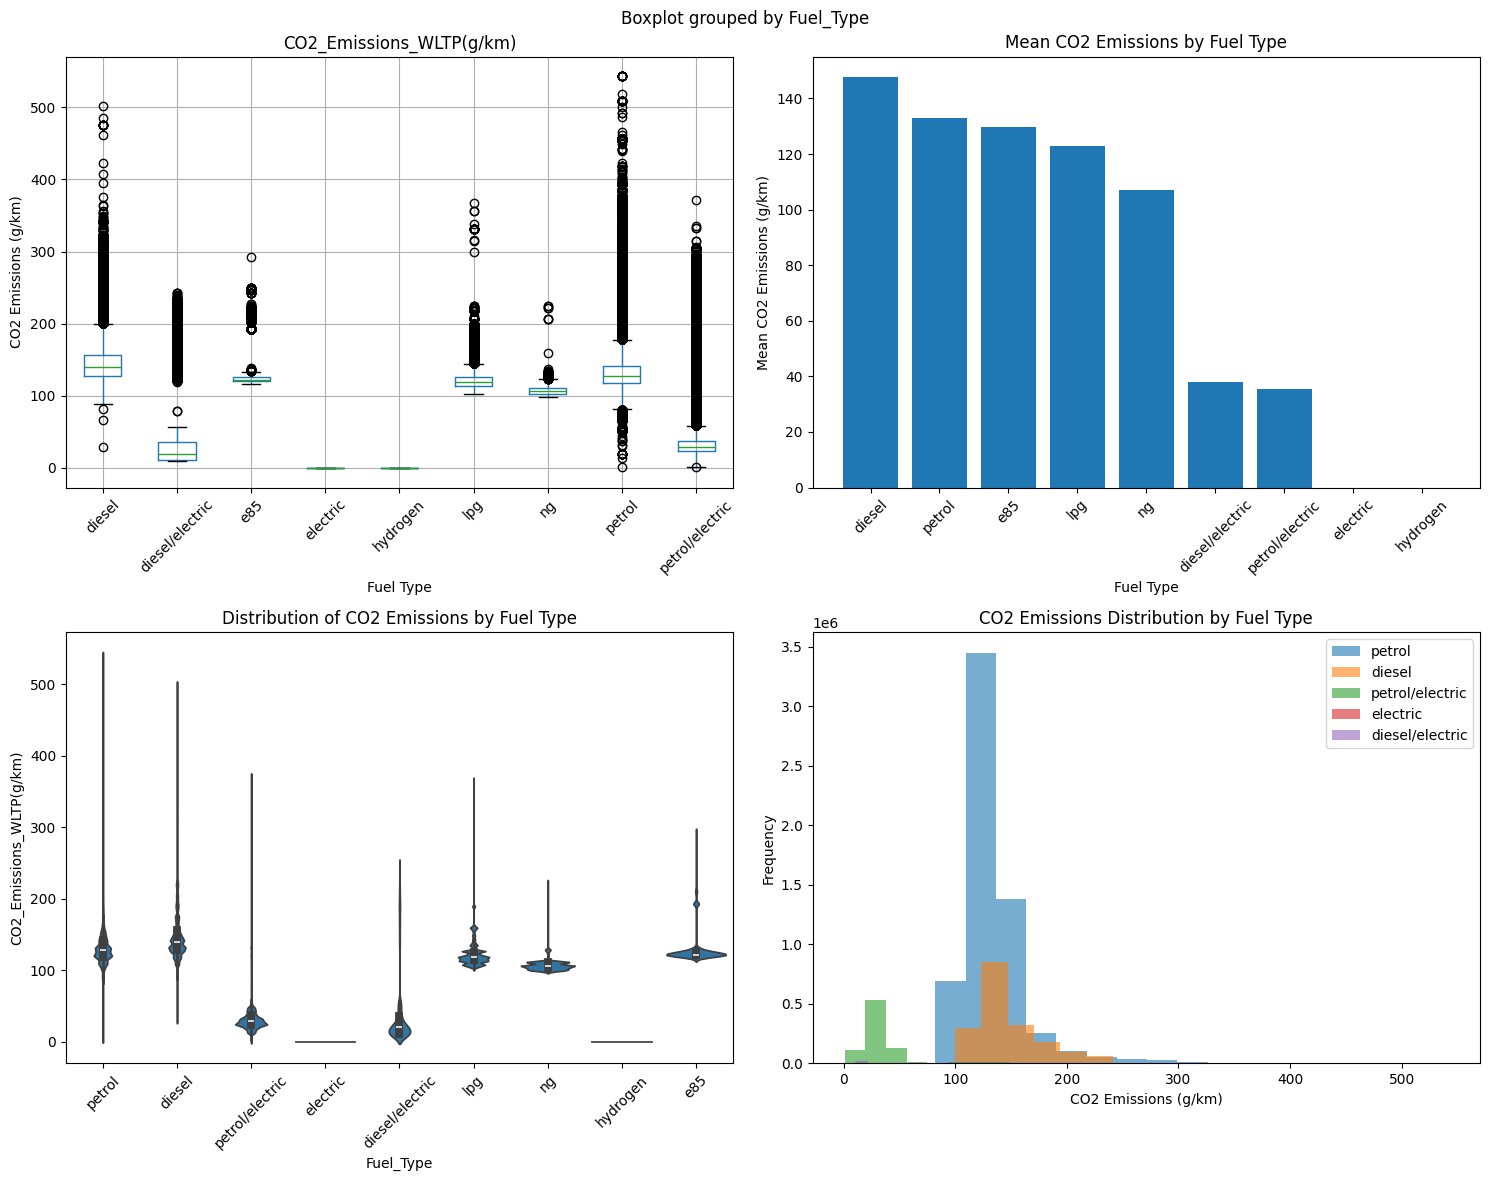


4. Effect Size:
Eta-squared: 0.8076
Effect size: Large

5. Post-hoc Analysis (Tukey's HSD):
Pairwise comparisons:
petrol vs diesel: p-value = 0.000000
petrol vs petrol/electric: p-value = 0.000000
petrol vs electric: p-value = 0.000000
petrol vs diesel/electric: p-value = 0.000000
petrol vs lpg: p-value = 0.000000
petrol vs ng: p-value = 0.000000
petrol vs hydrogen: p-value = 0.000000
petrol vs e85: p-value = 0.000000
diesel vs petrol/electric: p-value = 0.000000
diesel vs electric: p-value = 0.000000
diesel vs diesel/electric: p-value = 0.000000
diesel vs lpg: p-value = 0.000000
diesel vs ng: p-value = 0.000000
diesel vs hydrogen: p-value = 0.000000
diesel vs e85: p-value = 0.000000
petrol/electric vs electric: p-value = 0.000000
petrol/electric vs diesel/electric: p-value = 0.000000
petrol/electric vs lpg: p-value = 0.000000
petrol/electric vs ng: p-value = 0.000000
petrol/electric vs hydrogen: p-value = 0.000000
petrol/electric vs e85: p-value = 0.000000
electric vs diesel/electric

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

# 1. Exploratory Data Analysis
print("=== FUEL TYPE AND CO2 EMISSIONS ANALYSIS ===")
print("\n1. Basic Statistics:")
print(f"Total records: {len(df_a)}")
print(f"Fuel types: {df_a['Fuel_Type'].nunique()}")
print(f"Fuel type distribution:")
print(df_a['Fuel_Type'].value_counts())

# 2. Descriptive Statistics by Fuel Type
print("\n2. CO2 Emissions by Fuel Type:")
co2_by_fuel = df_a.groupby('Fuel_Type')['CO2_Emissions_WLTP(g/km)'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
print(co2_by_fuel)

# 3. Statistical Test - ANOVA
print("\n3. ANOVA Test:")
fuel_groups = []
for fuel_type in df_a['Fuel_Type'].unique():
    if pd.notna(fuel_type):  # Exclude NaN values
        group_data = df_a[df_a['Fuel_Type'] == fuel_type]['CO2_Emissions_WLTP(g/km)'].dropna()
        if len(group_data) > 0:
            fuel_groups.append(group_data)

# Perform ANOVA
f_stat, p_value = f_oneway(*fuel_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level: 0.05")
print(f"Result: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")

# 4. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Box plot
axes[0,0].set_title('CO2 Emissions by Fuel Type')
df_a.boxplot(column='CO2_Emissions_WLTP(g/km)', by='Fuel_Type', ax=axes[0,0])
axes[0,0].set_xlabel('Fuel Type')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].tick_params(axis='x', rotation=45)

# Bar plot of means
fuel_means = df_a.groupby('Fuel_Type')['CO2_Emissions_WLTP(g/km)'].mean().sort_values(ascending=False)
axes[0,1].bar(range(len(fuel_means)), fuel_means.values)
axes[0,1].set_title('Mean CO2 Emissions by Fuel Type')
axes[0,1].set_xlabel('Fuel Type')
axes[0,1].set_ylabel('Mean CO2 Emissions (g/km)')
axes[0,1].set_xticks(range(len(fuel_means)))
axes[0,1].set_xticklabels(fuel_means.index, rotation=45)

# Violin plot
sns.violinplot(data=df_a, x='Fuel_Type', y='CO2_Emissions_WLTP(g/km)', ax=axes[1,0])
axes[1,0].set_title('Distribution of CO2 Emissions by Fuel Type')
axes[1,0].tick_params(axis='x', rotation=45)

# Histogram
for fuel_type in df_a['Fuel_Type'].unique()[:5]:  # Show top 5 fuel types
    if pd.notna(fuel_type):
        data = df_a[df_a['Fuel_Type'] == fuel_type]['CO2_Emissions_WLTP(g/km)'].dropna()
        axes[1,1].hist(data, alpha=0.6, label=fuel_type, bins=20)
axes[1,1].set_title('CO2 Emissions Distribution by Fuel Type')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# 5. Effect Size (Eta-squared)
print(f"\n4. Effect Size:")
# Calculate eta-squared
ss_between = sum([len(group) * (group.mean() - df_a['CO2_Emissions_WLTP(g/km)'].mean())**2 
                  for group in fuel_groups])
ss_total = ((df_a['CO2_Emissions_WLTP(g/km)'] - df_a['CO2_Emissions_WLTP(g/km)'].mean())**2).sum()
eta_squared = ss_between / ss_total
print(f"Eta-squared: {eta_squared:.4f}")
print(f"Effect size: {'Small' if eta_squared < 0.01 else 'Medium' if eta_squared < 0.06 else 'Large'}")

# 6. Post-hoc analysis (if ANOVA is significant)
if p_value < 0.05:
    print("\n5. Post-hoc Analysis (Tukey's HSD):")
    from scipy.stats import tukey_hsd
    
    # Prepare data for Tukey's HSD
    fuel_types = []
    co2_values = []
    for fuel_type in df_a['Fuel_Type'].unique():
        if pd.notna(fuel_type):
            fuel_data = df_a[df_a['Fuel_Type'] == fuel_type]['CO2_Emissions_WLTP(g/km)'].dropna()
            fuel_types.extend([fuel_type] * len(fuel_data))
            co2_values.extend(fuel_data.values)
    
    # Perform Tukey's HSD
    try:
        tukey_result = tukey_hsd(*fuel_groups)
        print("Pairwise comparisons:")
        for i, fuel1 in enumerate(df_a['Fuel_Type'].unique()):
            for j, fuel2 in enumerate(df_a['Fuel_Type'].unique()):
                if i < j and pd.notna(fuel1) and pd.notna(fuel2):
                    print(f"{fuel1} vs {fuel2}: p-value = {tukey_result.pvalue[i,j]:.6f}")
    except:
        print("Tukey's HSD could not be performed - using alternative pairwise tests")

print("\n=== CONCLUSION ===")
if p_value < 0.05:
    print("There IS a statistically significant difference in CO2 emissions between fuel types.")
    print("This suggests that fuel type has a meaningful impact on CO2 emissions.")
else:
    print("There is NO statistically significant difference in CO2 emissions between fuel types.")
    print("This suggests that fuel type may not have a meaningful impact on CO2 emissions in this dataset.")

#### Does Type has a relationship with CO2 Emmissions

- Null Hypothesis (H₀): There is no significant difference in mean CO2 emissions between different vehicle types.
- Alternative Hypothesis (H₁): There is a significant difference in mean CO2 emissions between different vehicle types.
- Expected: Different vehicle types (sedan, SUV, hatchback, etc.) will have different CO2 emissions due to size, weight, and aerodynamic differences.

=== TYPE (TOP 10) AND CO2 EMISSIONS ANALYSIS ===
Original dataset: 10713765 records with 1727 unique types
Filtered dataset: 2510632 records with top 10 types
Coverage: 23.4% of original data

=== HYPOTHESIS ===
Null Hypothesis (H₀): There is no significant difference in mean CO2 emissions between different vehicle types.
Alternative Hypothesis (H₁): There is a significant difference in mean CO2 emissions between different vehicle types.
Expected: Different vehicle types (sedan, SUV, hatchback, etc.) will have different CO2 emissions due to size, weight, and aerodynamic differences.

1. Basic Statistics:
Filtered records: 2510632
Vehicle types analyzed: 10
Type distribution:
Type
U           628924
DJF         319895
312         262922
003         211425
CD          210334
RJA         209592
F           184985
A1          179043
XPB1F(M)    154899
SR          148613
Name: count, dtype: int64

2. CO2 Emissions by Vehicle Type:
           count  mean  median  std  min   max
Type         

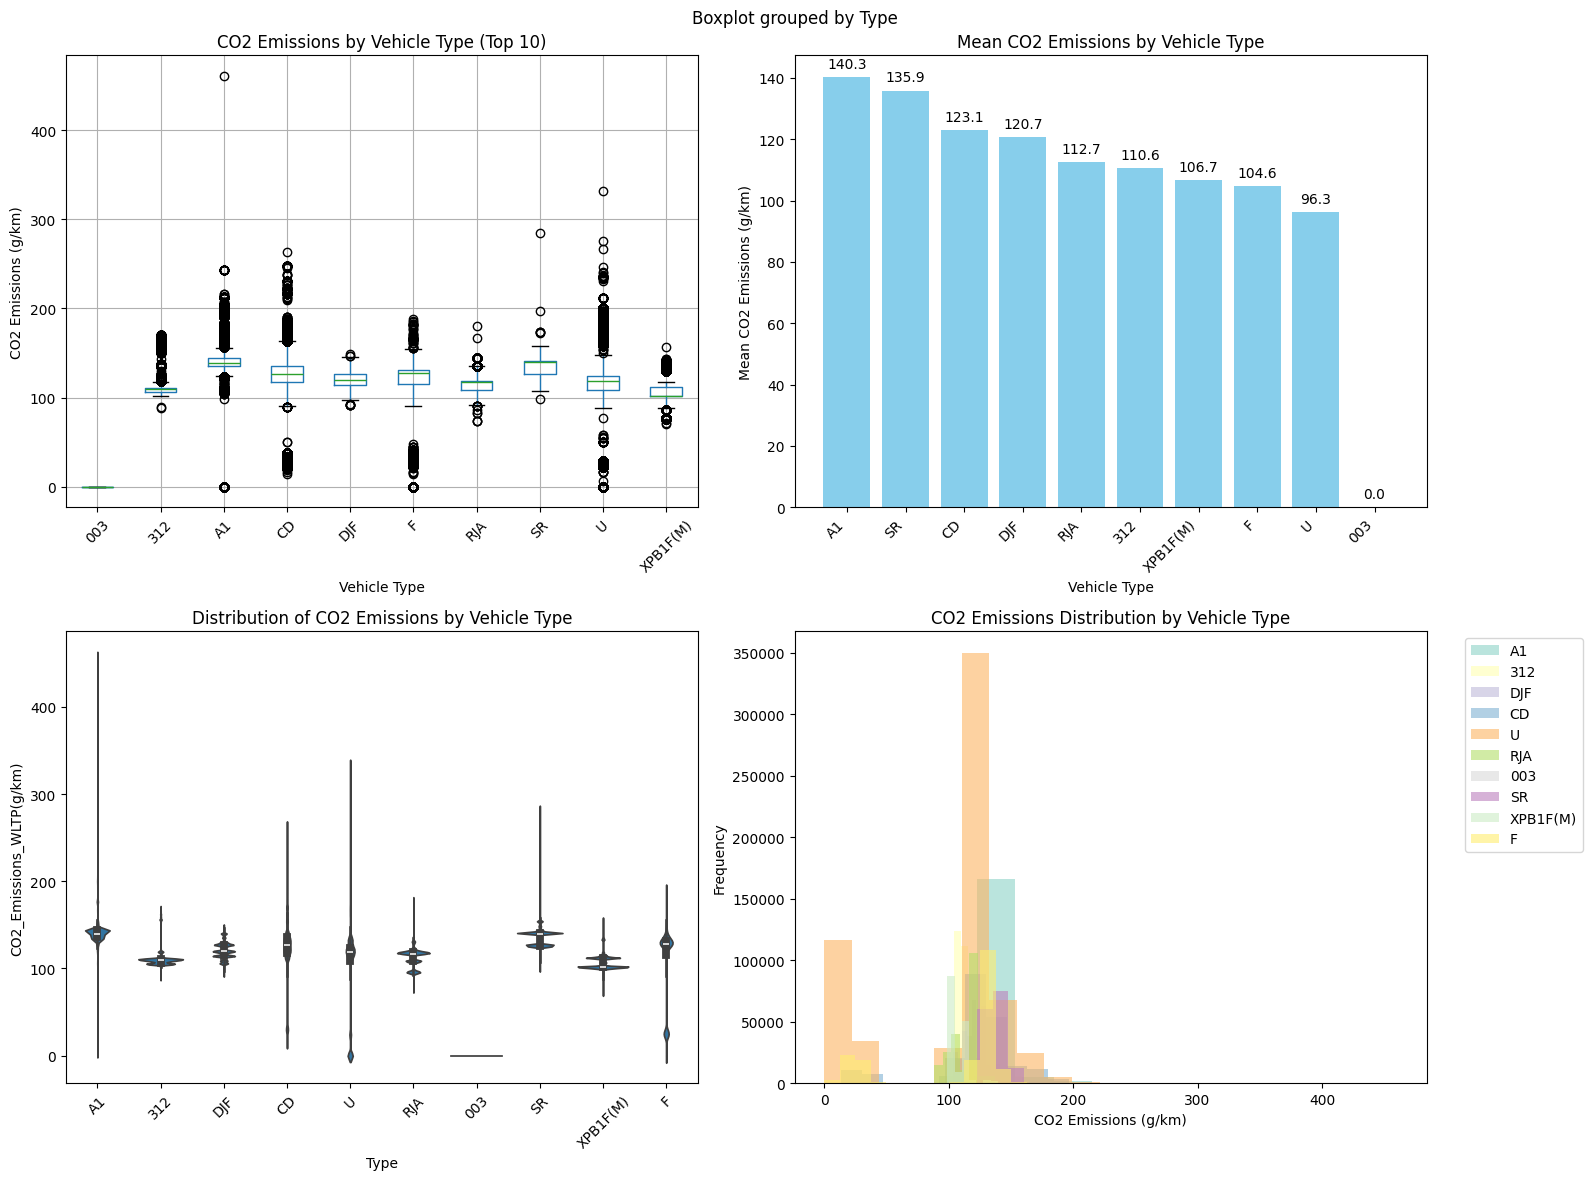


4. Effect Size:
Eta-squared: 0.5391
Effect size: Large

5. Post-hoc Analysis:
Significant pairwise comparisons (p < 0.05):
A1 vs 312: p-value = 0.000000, Mean difference = 29.68
A1 vs DJF: p-value = 0.000000, Mean difference = 19.66
A1 vs CD: p-value = 0.000000, Mean difference = 17.27
A1 vs U: p-value = 0.000000, Mean difference = 44.06
A1 vs RJA: p-value = 0.000000, Mean difference = 27.67
A1 vs 003: p-value = 0.000000, Mean difference = 140.33
A1 vs SR: p-value = 0.000000, Mean difference = 4.47
A1 vs XPB1F(M): p-value = 0.000000, Mean difference = 33.62
A1 vs F: p-value = 0.000000, Mean difference = 35.70
312 vs DJF: p-value = 0.000000, Mean difference = 10.03
312 vs CD: p-value = 0.000000, Mean difference = 12.42
312 vs U: p-value = 0.000000, Mean difference = 14.38
312 vs RJA: p-value = 0.000000, Mean difference = 2.01
312 vs 003: p-value = 0.000000, Mean difference = 110.64
312 vs SR: p-value = 0.000000, Mean difference = 25.22
312 vs XPB1F(M): p-value = 0.000000, Mean differen

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

# Focus on Top 10 Type categories only
print("=== TYPE (TOP 10) AND CO2 EMISSIONS ANALYSIS ===")

# Select top 10 most common types
top_types = df_a['Type'].value_counts().head(10).index
df_filtered = df_a[df_a['Type'].isin(top_types)].copy()

print(f"Original dataset: {len(df_a)} records with {df_a['Type'].nunique()} unique types")
print(f"Filtered dataset: {len(df_filtered)} records with top 10 types")
print(f"Coverage: {len(df_filtered)/len(df_a)*100:.1f}% of original data")

## Hypothesis
print("\n=== HYPOTHESIS ===")
print("Null Hypothesis (H₀): There is no significant difference in mean CO2 emissions between different vehicle types.")
print("Alternative Hypothesis (H₁): There is a significant difference in mean CO2 emissions between different vehicle types.")
print("Expected: Different vehicle types (sedan, SUV, hatchback, etc.) will have different CO2 emissions due to size, weight, and aerodynamic differences.")

# 1. Exploratory Data Analysis
print(f"\n1. Basic Statistics:")
print(f"Filtered records: {len(df_filtered)}")
print(f"Vehicle types analyzed: {df_filtered['Type'].nunique()}")
print(f"Type distribution:")
print(df_filtered['Type'].value_counts())

# 2. Descriptive Statistics by Type
print("\n2. CO2 Emissions by Vehicle Type:")
co2_by_type = df_filtered.groupby('Type')['CO2_Emissions_WLTP(g/km)'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
print(co2_by_type)

# 3. Statistical Test - ANOVA
print("\n3. ANOVA Test:")
type_groups = []
for vehicle_type in df_filtered['Type'].unique():
    if pd.notna(vehicle_type):  # Exclude NaN values
        group_data = df_filtered[df_filtered['Type'] == vehicle_type]['CO2_Emissions_WLTP(g/km)'].dropna()
        if len(group_data) > 0:
            type_groups.append(group_data)

# Perform ANOVA
f_stat, p_value = f_oneway(*type_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level: 0.05")
print(f"Result: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")

# 4. Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Box plot
df_filtered.boxplot(column='CO2_Emissions_WLTP(g/km)', by='Type', ax=axes[0,0])
axes[0,0].set_title('CO2 Emissions by Vehicle Type (Top 10)')
axes[0,0].set_xlabel('Vehicle Type')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].tick_params(axis='x', rotation=45)

# Bar plot of means
type_means = df_filtered.groupby('Type')['CO2_Emissions_WLTP(g/km)'].mean().sort_values(ascending=False)
axes[0,1].bar(range(len(type_means)), type_means.values, color='skyblue')
axes[0,1].set_title('Mean CO2 Emissions by Vehicle Type')
axes[0,1].set_xlabel('Vehicle Type')
axes[0,1].set_ylabel('Mean CO2 Emissions (g/km)')
axes[0,1].set_xticks(range(len(type_means)))
axes[0,1].set_xticklabels(type_means.index, rotation=45, ha='right')

# Add value labels on bars
for i, v in enumerate(type_means.values):
    axes[0,1].text(i, v + 2, f'{v:.1f}', ha='center', va='bottom')

# Violin plot
sns.violinplot(data=df_filtered, x='Type', y='CO2_Emissions_WLTP(g/km)', ax=axes[1,0])
axes[1,0].set_title('Distribution of CO2 Emissions by Vehicle Type')
axes[1,0].tick_params(axis='x', rotation=45)

# Histogram overlay
colors = plt.cm.Set3(np.linspace(0, 1, len(df_filtered['Type'].unique())))
for i, vehicle_type in enumerate(df_filtered['Type'].unique()):
    if pd.notna(vehicle_type):
        data = df_filtered[df_filtered['Type'] == vehicle_type]['CO2_Emissions_WLTP(g/km)'].dropna()
        axes[1,1].hist(data, alpha=0.6, label=vehicle_type, bins=15, color=colors[i])

axes[1,1].set_title('CO2 Emissions Distribution by Vehicle Type')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 5. Effect Size (Eta-squared)
print(f"\n4. Effect Size:")
# Calculate eta-squared
ss_between = sum([len(group) * (group.mean() - df_filtered['CO2_Emissions_WLTP(g/km)'].mean())**2 
                  for group in type_groups])
ss_total = ((df_filtered['CO2_Emissions_WLTP(g/km)'] - df_filtered['CO2_Emissions_WLTP(g/km)'].mean())**2).sum()
eta_squared = ss_between / ss_total
print(f"Eta-squared: {eta_squared:.4f}")
print(f"Effect size: {'Small' if eta_squared < 0.01 else 'Medium' if eta_squared < 0.06 else 'Large'}")

# 6. Post-hoc analysis (if ANOVA is significant)
if p_value < 0.05:
    print("\n5. Post-hoc Analysis:")
    from scipy.stats import tukey_hsd
    
    try:
        tukey_result = tukey_hsd(*type_groups)
        type_names = df_filtered['Type'].unique()
        print("Significant pairwise comparisons (p < 0.05):")
        
        significant_pairs = []
        for i, type1 in enumerate(type_names):
            for j, type2 in enumerate(type_names):
                if i < j and pd.notna(type1) and pd.notna(type2):
                    p_val = tukey_result.pvalue[i,j]
                    if p_val < 0.05:
                        mean1 = df_filtered[df_filtered['Type'] == type1]['CO2_Emissions_WLTP(g/km)'].mean()
                        mean2 = df_filtered[df_filtered['Type'] == type2]['CO2_Emissions_WLTP(g/km)'].mean()
                        significant_pairs.append((type1, type2, p_val, abs(mean1-mean2)))
                        print(f"{type1} vs {type2}: p-value = {p_val:.6f}, Mean difference = {abs(mean1-mean2):.2f}")
        
        if not significant_pairs:
            print("No significant pairwise differences found.")
            
    except Exception as e:
        print(f"Tukey's HSD could not be performed: {e}")

# 7. Summary Statistics Table
print("\n6. Summary Comparison:")
summary_stats = df_filtered.groupby('Type')['CO2_Emissions_WLTP(g/km)'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Std Dev', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).round(2).sort_values('Mean', ascending=False)

print(summary_stats)

print("\n=== CONCLUSION ===")
if p_value < 0.05:
    print("There IS a statistically significant difference in CO2 emissions between different vehicle types.")
    print("This suggests that vehicle type has a meaningful impact on CO2 emissions.")
    print(f"The effect size is {eta_squared:.4f}, which is considered {'small' if eta_squared < 0.01 else 'medium' if eta_squared < 0.06 else 'large'}.")
    
    # Identify highest and lowest emitting types
    highest_type = type_means.index[0]
    lowest_type = type_means.index[-1]
    print(f"Highest emitting type: {highest_type} ({type_means.iloc[0]:.1f} g/km)")
    print(f"Lowest emitting type: {lowest_type} ({type_means.iloc[-1]:.1f} g/km)")
    print(f"Difference: {type_means.iloc[0] - type_means.iloc[-1]:.1f} g/km")
else:
    print("There is NO statistically significant difference in CO2 emissions between vehicle types.")
    print("This suggests that vehicle type may not have a meaningful impact on CO2 emissions in this dataset.")

#### Does Innovative Technologies has a relationship with CO2 Emmissions

=== INNOVATIVE TECHNOLOGIES (TOP CATEGORIES) AND CO2 EMISSIONS ANALYSIS ===
Exploring Innovative_Technologies variable:
Total unique technologies: 269
Total records: 10713765

Technologies with ≥50 observations: 145
Technologies with ≥20 observations: 168
Technologies with ≥10 observations: 185
Technologies with <5 observations: 69

Top 15 most common technologies:
Innovative_Technologies
e2 29 37     776728
e9 29 37     732815
e6 37        494871
e1 29        443782
e13 29       377402
e13 29 37    301590
e8 29 37     290527
e2 28 29     284532
e2 37        200856
e3 33        199830
e5 29        160680
e19 29 37    145770
e2 29        125910
e9 32 37     124858
e13 37       121121
Name: count, dtype: int64

=== ANALYSIS SCOPE ===
Technologies with ≥20 observations: 168
Filtered dataset: 6458396 records
Coverage: 60.3% of original data

Reduced to top 15 technologies for manageable analysis:
Final dataset: 4781272 records
Final coverage: 44.6% of original data

=== HYPOTHESIS ===
Null

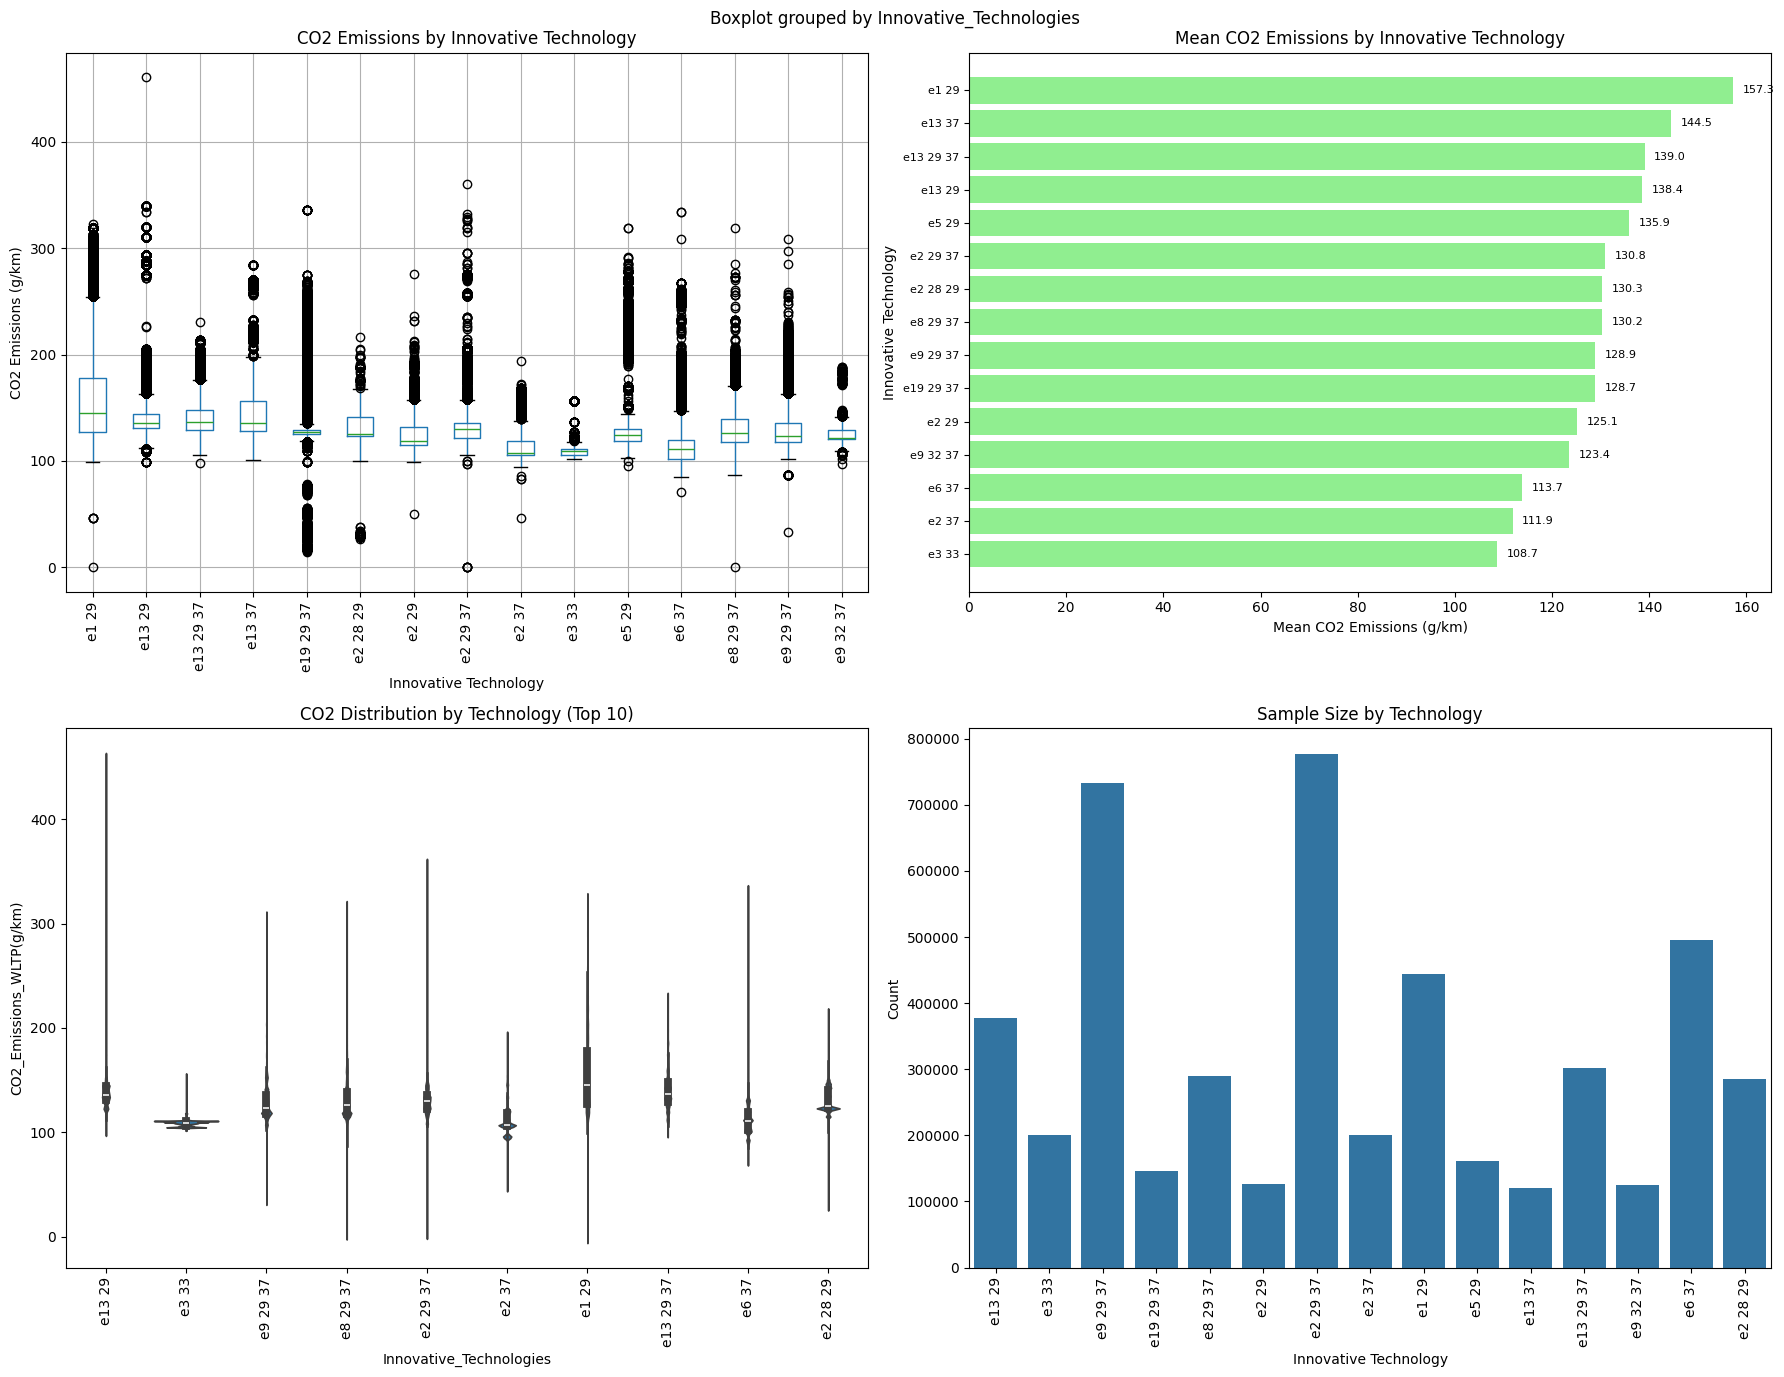


4. Effect Size:
Eta-squared: 0.2702
Effect size: Large

5. Technology Effectiveness Ranking (Lowest to Highest CO2):
                         Mean_CO2  Sample_Size
Innovative_Technologies                       
e3 33                       108.7       199830
e2 37                       111.9       200856
e6 37                       113.7       494871
e9 32 37                    123.4       124858
e2 29                       125.1       125910
e19 29 37                   128.8       145770
e9 29 37                    128.9       732815
e8 29 37                    130.2       290527
e2 28 29                    130.3       284532
e2 29 37                    130.8       776728
e5 29                       135.9       160680
e13 29                      138.4       377402
e13 29 37                   139.0       301590
e13 37                      144.5       121121
e1 29                       157.3       443782

6. Key Findings:
Most effective technology: e3 33 (108.72 g/km)
Least effective te

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

print("=== INNOVATIVE TECHNOLOGIES (TOP CATEGORIES) AND CO2 EMISSIONS ANALYSIS ===")

# First, let's explore the distribution
print("Exploring Innovative_Technologies variable:")
print(f"Total unique technologies: {df_a['Innovative_Technologies'].nunique()}")
print(f"Total records: {len(df_a)}")

# Check the distribution
tech_counts = df_a['Innovative_Technologies'].value_counts()
print(f"\nTechnologies with ≥50 observations: {(tech_counts >= 50).sum()}")
print(f"Technologies with ≥20 observations: {(tech_counts >= 20).sum()}")
print(f"Technologies with ≥10 observations: {(tech_counts >= 10).sum()}")
print(f"Technologies with <5 observations: {(tech_counts < 5).sum()}")

# Show top 15 to see patterns
print(f"\nTop 15 most common technologies:")
print(tech_counts.head(15))

# Strategy: Use top categories that have sufficient sample size (≥20 observations)
min_observations = 20
top_technologies = tech_counts[tech_counts >= min_observations].index
df_filtered = df_a[df_a['Innovative_Technologies'].isin(top_technologies)].copy()

print(f"\n=== ANALYSIS SCOPE ===")
print(f"Technologies with ≥{min_observations} observations: {len(top_technologies)}")
print(f"Filtered dataset: {len(df_filtered)} records")
print(f"Coverage: {len(df_filtered)/len(df_a)*100:.1f}% of original data")

# If still too many categories, further reduce to top 15
if len(top_technologies) > 15:
    top_15_technologies = tech_counts.head(15).index
    df_filtered = df_a[df_a['Innovative_Technologies'].isin(top_15_technologies)].copy()
    print(f"\nReduced to top 15 technologies for manageable analysis:")
    print(f"Final dataset: {len(df_filtered)} records")
    print(f"Final coverage: {len(df_filtered)/len(df_a)*100:.1f}% of original data")

## Hypothesis
print("\n=== HYPOTHESIS ===")
print("Null Hypothesis (H₀): There is no significant difference in mean CO2 emissions between different innovative technologies.")
print("Alternative Hypothesis (H₁): There is a significant difference in mean CO2 emissions between different innovative technologies.")
print("Expected: Different innovative technologies will show varying levels of CO2 emission reduction effectiveness.")

# 1. Exploratory Data Analysis
print(f"\n1. Basic Statistics:")
print(f"Technologies analyzed: {df_filtered['Innovative_Technologies'].nunique()}")
print(f"Technology distribution in filtered data:")
filtered_tech_counts = df_filtered['Innovative_Technologies'].value_counts()
print(filtered_tech_counts)

# 2. Descriptive Statistics by Technology
print("\n2. CO2 Emissions by Innovative Technology:")
co2_by_tech = df_filtered.groupby('Innovative_Technologies')['CO2_Emissions_WLTP(g/km)'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
print(co2_by_tech.sort_values('mean'))

# 3. Statistical Test - ANOVA
print("\n3. ANOVA Test:")
tech_groups = []
for technology in df_filtered['Innovative_Technologies'].unique():
    if pd.notna(technology):
        group_data = df_filtered[df_filtered['Innovative_Technologies'] == technology]['CO2_Emissions_WLTP(g/km)'].dropna()
        if len(group_data) > 0:
            tech_groups.append(group_data)

# Perform ANOVA
if len(tech_groups) > 1:
    f_stat, p_value = f_oneway(*tech_groups)
    print(f"F-statistic: {f_stat:.4f}")
    print(f"P-value: {p_value:.6f}")
    print(f"Significance level: 0.05")
    print(f"Result: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")
else:
    print("Insufficient groups for ANOVA")
    p_value = 1.0

# 4. Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Box plot
df_filtered.boxplot(column='CO2_Emissions_WLTP(g/km)', by='Innovative_Technologies', ax=axes[0,0])
axes[0,0].set_title('CO2 Emissions by Innovative Technology')
axes[0,0].set_xlabel('Innovative Technology')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].tick_params(axis='x', rotation=90)

# Bar plot of means
tech_means = df_filtered.groupby('Innovative_Technologies')['CO2_Emissions_WLTP(g/km)'].mean().sort_values(ascending=True)
axes[0,1].barh(range(len(tech_means)), tech_means.values, color='lightgreen')
axes[0,1].set_title('Mean CO2 Emissions by Innovative Technology')
axes[0,1].set_xlabel('Mean CO2 Emissions (g/km)')
axes[0,1].set_ylabel('Innovative Technology')
axes[0,1].set_yticks(range(len(tech_means)))
axes[0,1].set_yticklabels(tech_means.index, fontsize=8)

# Add value labels on bars
for i, v in enumerate(tech_means.values):
    axes[0,1].text(v + 2, i, f'{v:.1f}', va='center', fontsize=8)

# Violin plot (show only top 10 for readability)
top_10_tech = filtered_tech_counts.head(10).index
df_top10 = df_filtered[df_filtered['Innovative_Technologies'].isin(top_10_tech)]
sns.violinplot(data=df_top10, x='Innovative_Technologies', y='CO2_Emissions_WLTP(g/km)', ax=axes[1,0])
axes[1,0].set_title('CO2 Distribution by Technology (Top 10)')
axes[1,0].tick_params(axis='x', rotation=90)

# Count plot
sns.countplot(data=df_filtered, x='Innovative_Technologies', ax=axes[1,1])
axes[1,1].set_title('Sample Size by Technology')
axes[1,1].set_xlabel('Innovative Technology')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# 5. Effect Size (Eta-squared)
if len(tech_groups) > 1:
    print(f"\n4. Effect Size:")
    ss_between = sum([len(group) * (group.mean() - df_filtered['CO2_Emissions_WLTP(g/km)'].mean())**2 
                      for group in tech_groups])
    ss_total = ((df_filtered['CO2_Emissions_WLTP(g/km)'] - df_filtered['CO2_Emissions_WLTP(g/km)'].mean())**2).sum()
    eta_squared = ss_between / ss_total
    print(f"Eta-squared: {eta_squared:.4f}")
    print(f"Effect size: {'Small' if eta_squared < 0.01 else 'Medium' if eta_squared < 0.06 else 'Large'}")

# 6. Technology Effectiveness Ranking
print("\n5. Technology Effectiveness Ranking (Lowest to Highest CO2):")
tech_effectiveness = df_filtered.groupby('Innovative_Technologies').agg({
    'CO2_Emissions_WLTP(g/km)': ['mean', 'count']
}).round(2)
tech_effectiveness.columns = ['Mean_CO2', 'Sample_Size']
tech_effectiveness = tech_effectiveness.sort_values('Mean_CO2')
print(tech_effectiveness)

# 7. Statistical significance analysis
if p_value < 0.05 and len(tech_groups) > 1:
    print("\n6. Key Findings:")
    best_tech = tech_effectiveness.index[0]
    worst_tech = tech_effectiveness.index[-1]
    best_co2 = tech_effectiveness.loc[best_tech, 'Mean_CO2']
    worst_co2 = tech_effectiveness.loc[worst_tech, 'Mean_CO2']
    
    print(f"Most effective technology: {best_tech} ({best_co2} g/km)")
    print(f"Least effective technology: {worst_tech} ({worst_co2} g/km)")
    print(f"Difference: {worst_co2 - best_co2:.1f} g/km")
    
    # Technologies significantly better than average
    overall_mean = df_filtered['CO2_Emissions_WLTP(g/km)'].mean()
    better_than_avg = tech_effectiveness[tech_effectiveness['Mean_CO2'] < overall_mean]
    print(f"\nTechnologies with below-average emissions ({overall_mean:.1f} g/km):")
    print(better_than_avg)

print("\n=== CONCLUSION ===")
if p_value < 0.05:
    print("There IS a statistically significant difference in CO2 emissions between different innovative technologies.")
    print("This confirms that innovative technologies have measurably different impacts on CO2 emissions.")
    if 'eta_squared' in locals():
        print(f"The effect size is {eta_squared:.4f}, indicating a {'small' if eta_squared < 0.01 else 'medium' if eta_squared < 0.06 else 'large'} practical impact.")
else:
    print("There is NO statistically significant difference in CO2 emissions between innovative technologies.")
    print("This suggests the technologies analyzed may have similar emission impacts, or more data may be needed.")

# 8. Additional insight: Check for patterns in technology names
print("\n7. Technology Pattern Analysis:")
all_techs = df_a['Innovative_Technologies'].dropna().astype(str)
print("Common patterns in technology names:")
patterns = {}
for tech in all_techs:
    words = tech.split()
    for word in words:
        if len(word) > 2:  # Ignore very short words
            patterns[word] = patterns.get(word, 0) + 1

# Show most common words/patterns
common_patterns = sorted(patterns.items(), key=lambda x: x[1], reverse=True)[:10]
print("Most common words in technology descriptions:")
for pattern, count in common_patterns:
    print(f"{pattern}: {count} occurrences")

#### Does the Engine_Capacity(cm3) has a relationship with CO2 Emmisions?

- Null Hypothesis (H₀): There is no linear relationship between engine capacity and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between engine capacity and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.

=== ENGINE CAPACITY AND CO2 EMISSIONS CORRELATION ANALYSIS ===

=== HYPOTHESIS ===
Null Hypothesis (H₀): There is no linear relationship between engine capacity and CO2 emissions.
Alternative Hypothesis (H₁): There is a significant linear relationship between engine capacity and CO2 emissions.
Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.

1. Data Overview:
Total records: 10713765
Records with both variables: 9043496
Missing values removed: 1670269

2. Descriptive Statistics:
Engine Capacity (cm³):
  Mean: 1543.17
  Median: 1497.00
  Std Dev: 524.22
  Range: 658 - 7993

CO2 Emissions (g/km):
  Mean: 126.36
  Median: 128.00
  Std Dev: 41.40
  Range: 0 - 543

3. Correlation Analysis:
Pearson Correlation Coefficient: 0.291650
Pearson P-value: 0.000000
Spearman Correlation Coefficient: 0.290801
Spearman P-value: 0.000000

Correlation Strength Interpretation:
Pearson: Weak positive linear relationship
Spearman: Weak positive m

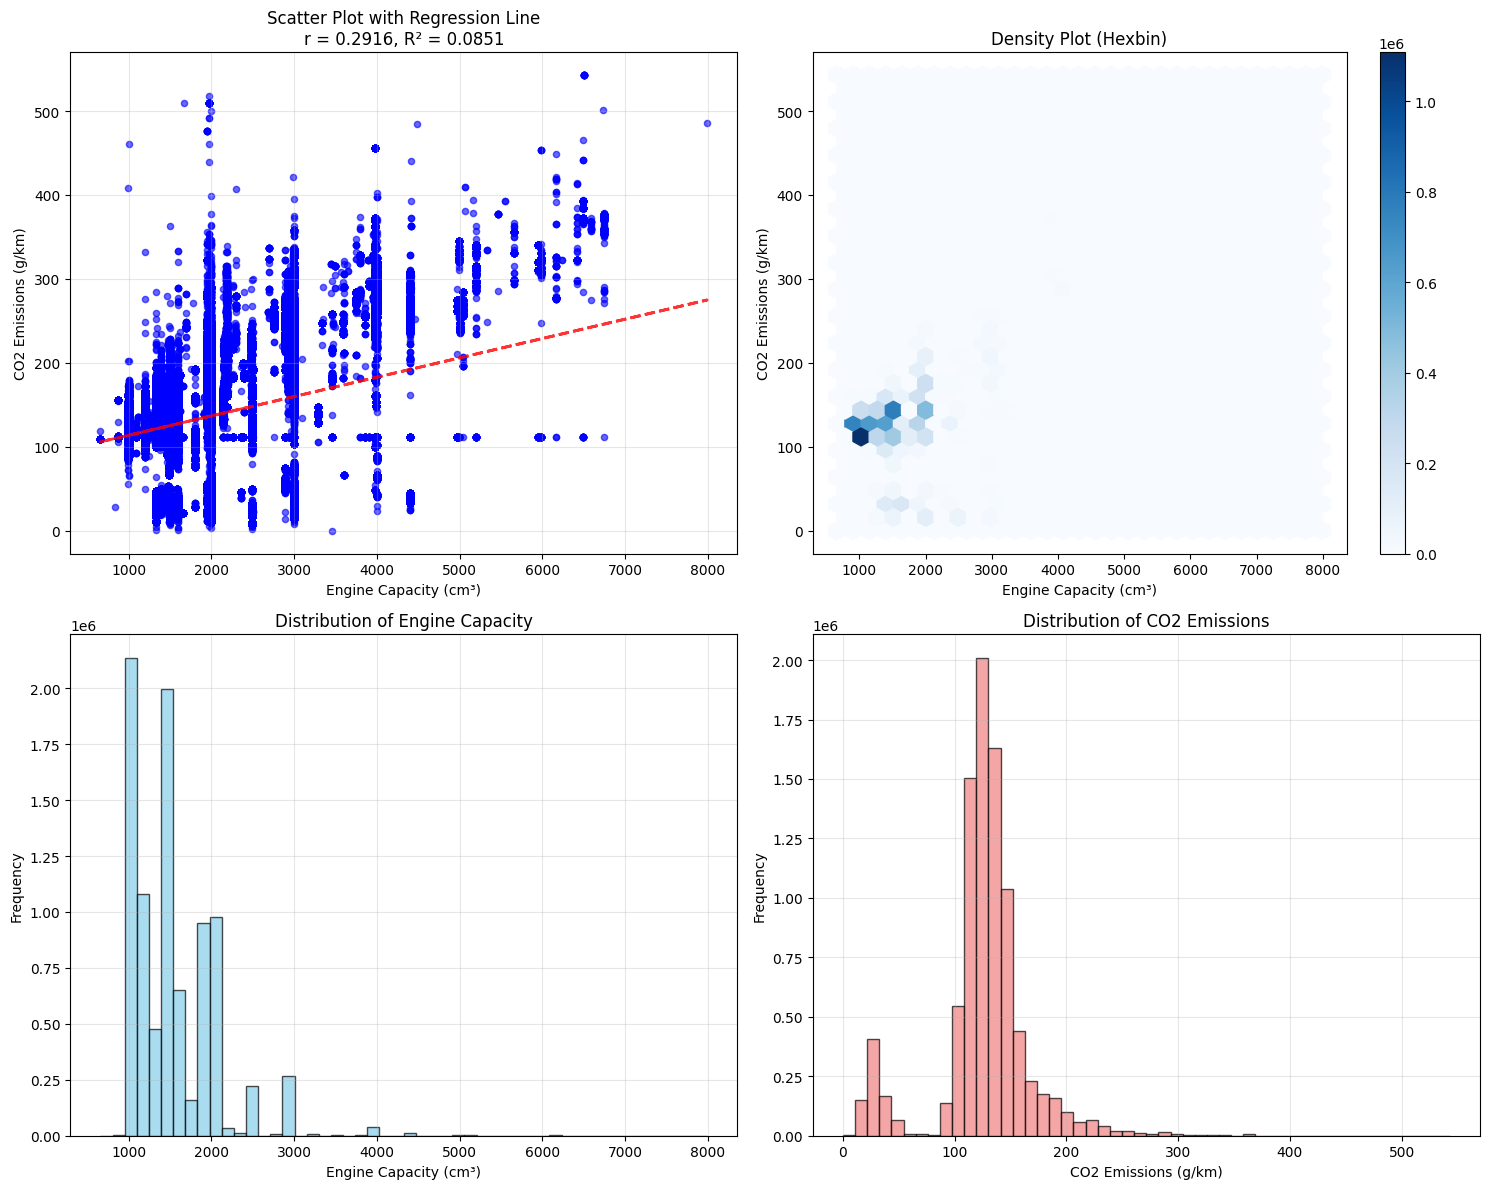


6. Linear Regression Analysis:
Linear Regression Equation: CO2 = 90.8161 + 0.0230 × Engine_Capacity
Mean Squared Error (MSE): 1568.5456
Root Mean Squared Error (RMSE): 39.6049
Mean Absolute Error (MAE): 25.3843


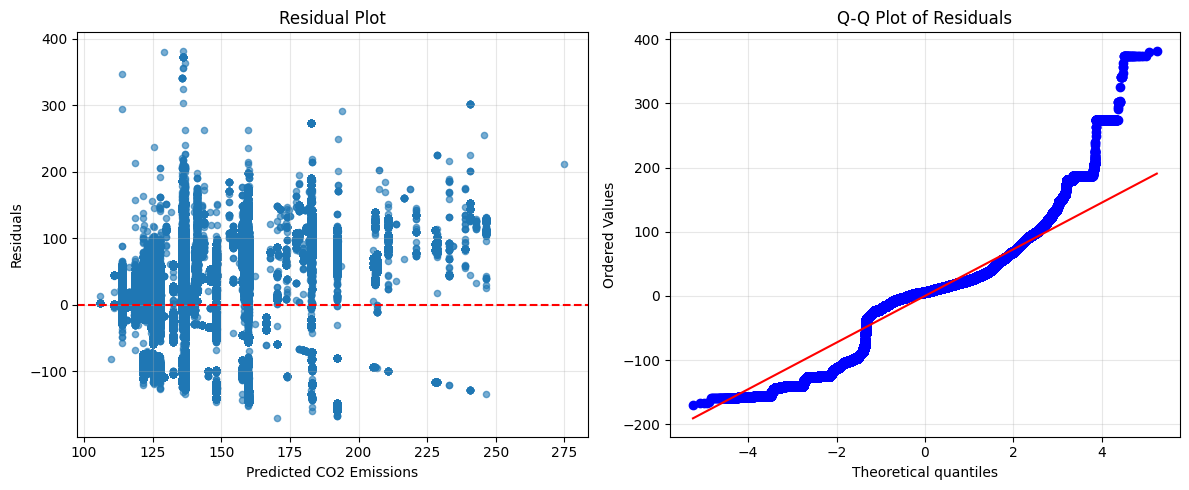


7. Binned Analysis:
                        count  mean  median  std
Engine_Capacity_Bins                            
Very Small            8425153 124.1   127.0 34.9
Small                  552789 143.6   158.0 76.7
Medium                  61290 271.9   285.0 72.4
Large                    3883 317.9   316.0 50.0
Very Large                381 366.0   372.0 22.1

=== CONCLUSION ===
There IS a statistically significant linear relationship between engine capacity and CO2 emissions.
The correlation is weak and positive.
Engine capacity explains 8.51% of the variance in CO2 emissions.
As engine capacity increases, CO2 emissions tend to increase.
For every 1000 cm³ increase in engine capacity, CO2 emissions change by 23.04 g/km on average.

Note: If Spearman correlation (0.2908) is much different from Pearson correlation (0.2916),
this suggests a non-linear monotonic relationship might exist.


In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== ENGINE CAPACITY AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

## Hypothesis
print("\n=== HYPOTHESIS ===")
print("Null Hypothesis (H₀): There is no linear relationship between engine capacity and CO2 emissions.")
print("Alternative Hypothesis (H₁): There is a significant linear relationship between engine capacity and CO2 emissions.")
print("Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.")

# 1. Data Overview
print(f"\n1. Data Overview:")
print(f"Total records: {len(df_a)}")

# Remove missing values for analysis
df_clean = df_a[['Engine_Capacity(cm3)', 'CO2_Emissions_WLTP(g/km)']].dropna()
print(f"Records with both variables: {len(df_clean)}")
print(f"Missing values removed: {len(df_a) - len(df_clean)}")

# 2. Descriptive Statistics
print(f"\n2. Descriptive Statistics:")
print("Engine Capacity (cm³):")
print(f"  Mean: {df_clean['Engine_Capacity(cm3)'].mean():.2f}")
print(f"  Median: {df_clean['Engine_Capacity(cm3)'].median():.2f}")
print(f"  Std Dev: {df_clean['Engine_Capacity(cm3)'].std():.2f}")
print(f"  Range: {df_clean['Engine_Capacity(cm3)'].min():.0f} - {df_clean['Engine_Capacity(cm3)'].max():.0f}")

print(f"\nCO2 Emissions (g/km):")
print(f"  Mean: {df_clean['CO2_Emissions_WLTP(g/km)'].mean():.2f}")
print(f"  Median: {df_clean['CO2_Emissions_WLTP(g/km)'].median():.2f}")
print(f"  Std Dev: {df_clean['CO2_Emissions_WLTP(g/km)'].std():.2f}")
print(f"  Range: {df_clean['CO2_Emissions_WLTP(g/km)'].min():.0f} - {df_clean['CO2_Emissions_WLTP(g/km)'].max():.0f}")

# 3. Correlation Analysis
print(f"\n3. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by engine capacity")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
axes[0,0].scatter(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_clean['Engine_Capacity(cm3)'], p(df_clean['Engine_Capacity(cm3)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Engine Capacity (cm³)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Engine Capacity (cm³)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_clean['Engine_Capacity(cm3)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Engine Capacity (cm³)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Engine Capacity')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_clean['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. Residual Analysis
print(f"\n6. Linear Regression Analysis:")
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Prepare data
X = df_clean['Engine_Capacity(cm3)'].values.reshape(-1, 1)
y = df_clean['CO2_Emissions_WLTP(g/km)'].values

# Fit model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate metrics
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mse)

print(f"Linear Regression Equation: CO2 = {model.intercept_:.4f} + {model.coef_[0]:.4f} × Engine_Capacity")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Residual plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
residuals = y - y_pred
plt.scatter(y_pred, residuals, alpha=0.6, s=20)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted CO2 Emissions')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Binned Analysis
print(f"\n7. Binned Analysis:")
# Create bins for engine capacity
df_clean['Engine_Capacity_Bins'] = pd.cut(df_clean['Engine_Capacity(cm3)'], 
                                          bins=5, labels=['Very Small', 'Small', 'Medium', 'Large', 'Very Large'])

binned_stats = df_clean.groupby('Engine_Capacity_Bins')['CO2_Emissions_WLTP(g/km)'].agg([
    'count', 'mean', 'median', 'std'
]).round(2)
print(binned_stats)

print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
    # Practical interpretation
    slope = model.coef_[0]
    print(f"For every 1000 cm³ increase in engine capacity, CO2 emissions change by {slope*1000:.2f} g/km on average.")
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")